## Series Temporales

In [1]:
from statsmodels.tsa.stattools import adfuller
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

In [2]:
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\05 Series temporales'

###  0.Importamos los datos
Nos traemos la serie dle banco de España BE2315 de viajeros de avion desde enero 2004 hasta feb 2025.
https://www.bde.es/webbe/es/estadisticas/compartido/datos/zip/SB_SERVICIOS.zip

In [3]:
file='data\\BE2315_num_pasajeros_ES.csv'
df = pd.read_csv(file, delimiter=',', low_memory=False)
df.shape
#os.getcwd()
print(df.head())

     fecha  num personas
0  2004-01       9979352
1  2004-02      11008703
2  2004-03      12434592
3  2004-04      13288475
4  2004-05      14325765


In [4]:
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')
df

,num personas
fecha,
2004-01-01,9979352
2004-02-01,11008703
2004-03-01,12434592
2004-04-01,13288475
2004-05-01,14325765
...,...
2024-10-01,28251591
2024-11-01,21560768
2024-12-01,21703760


In [5]:
ts = df['num personas']
ts

fecha
2004-01-01     9979352
2004-02-01    11008703
2004-03-01    12434592
2004-04-01    13288475
2004-05-01    14325765
                ...   
2024-10-01    28251591
2024-11-01    21560768
2024-12-01    21703760
2025-01-01    19801425
2025-02-01    19993427
Name: num personas, Length: 254, dtype: int64

#### 1. Visualizamos la serie temporal

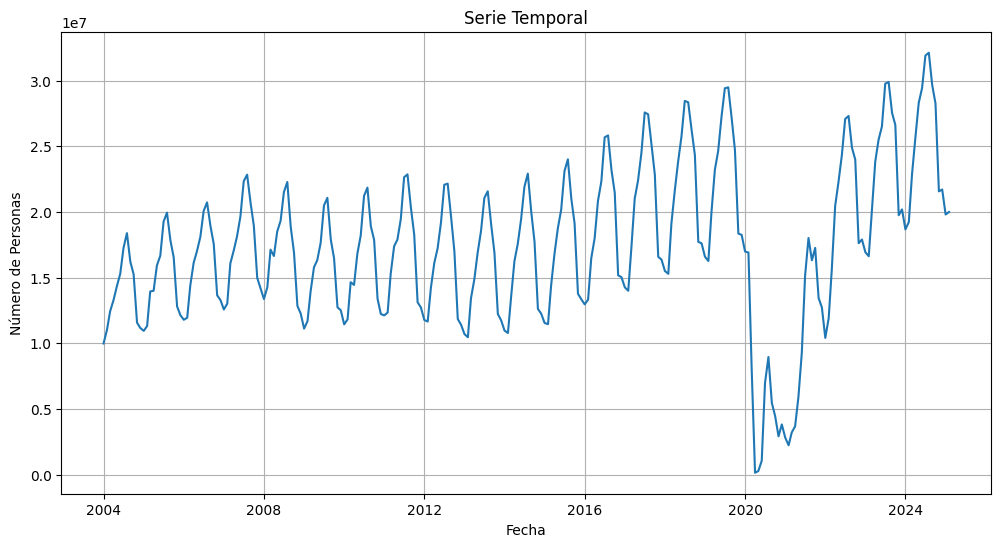

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(ts, linestyle='-')

plt.xlabel('Fecha')
plt.ylabel('Número de Personas')
plt.title('Serie Temporal')
plt.grid(True)

plt.show()

#### 2. Análisis de la serie temporal

####  2.1 Estacionaridad
Una serie es **estacionaria** si su media y varianza permanecen constantes en el tiempo. El **test de Dickey-Fuller aumentado (ADF)** nos ayuda a determinar si la serie es o no estacionaria.  

**Hipótesis nula:** la serie no es estacionaria (tiene raíz unitaria).

* Si el valor p < 0.05, rechazas la hipótesis nula → la serie es estacionaria.
* Si el valor p > 0.05, no puedes rechazar la nula → la serie es no estacionaria → necesitas diferenciarla.

In [10]:
def test_stationarity(timeseries):
    # Perform the ADF test
    result = adfuller(timeseries)
    
    # Print the test statistic and p-value
    print("Test statistic:", result[0])
    print("p-value:", result[1])
    
    # Check the p-value
    if result[1] < 0.05:
        print("Time series is stationary")
    else:
        print("Time series is non-stationary")


In [11]:
test_stationarity(ts) 

Test statistic: -3.555249748203462
p-value: 0.006676495466161411
Time series is stationary


In [12]:
test_stationarity(ts.diff().dropna()) 

Test statistic: -3.640189568974006
p-value: 0.0050375737714549035
Time series is stationary


#### 2.2 Autocorrelación
Vemos cuan correlada esta la serie con sus valores pasados de 1 a 12 observaciones pasadas

In [13]:
autocorr = [ts.autocorr(lag=i) for i in range(1, 12)]

# Print the autocorrelation values
print(autocorr)  

[0.9137491435840244, 0.7483452798132404, 0.534378015391461, 0.3274803626495986, 0.18009666135159844, 0.09330021148004616, 0.09443079264642298, 0.16656383491818672, 0.30121389329419435, 0.44406699714087866, 0.5405635634042347]


#### 2.3 Descomposición de la serie
Descomponemos la serie en tendencia, estacionalidad y residuo

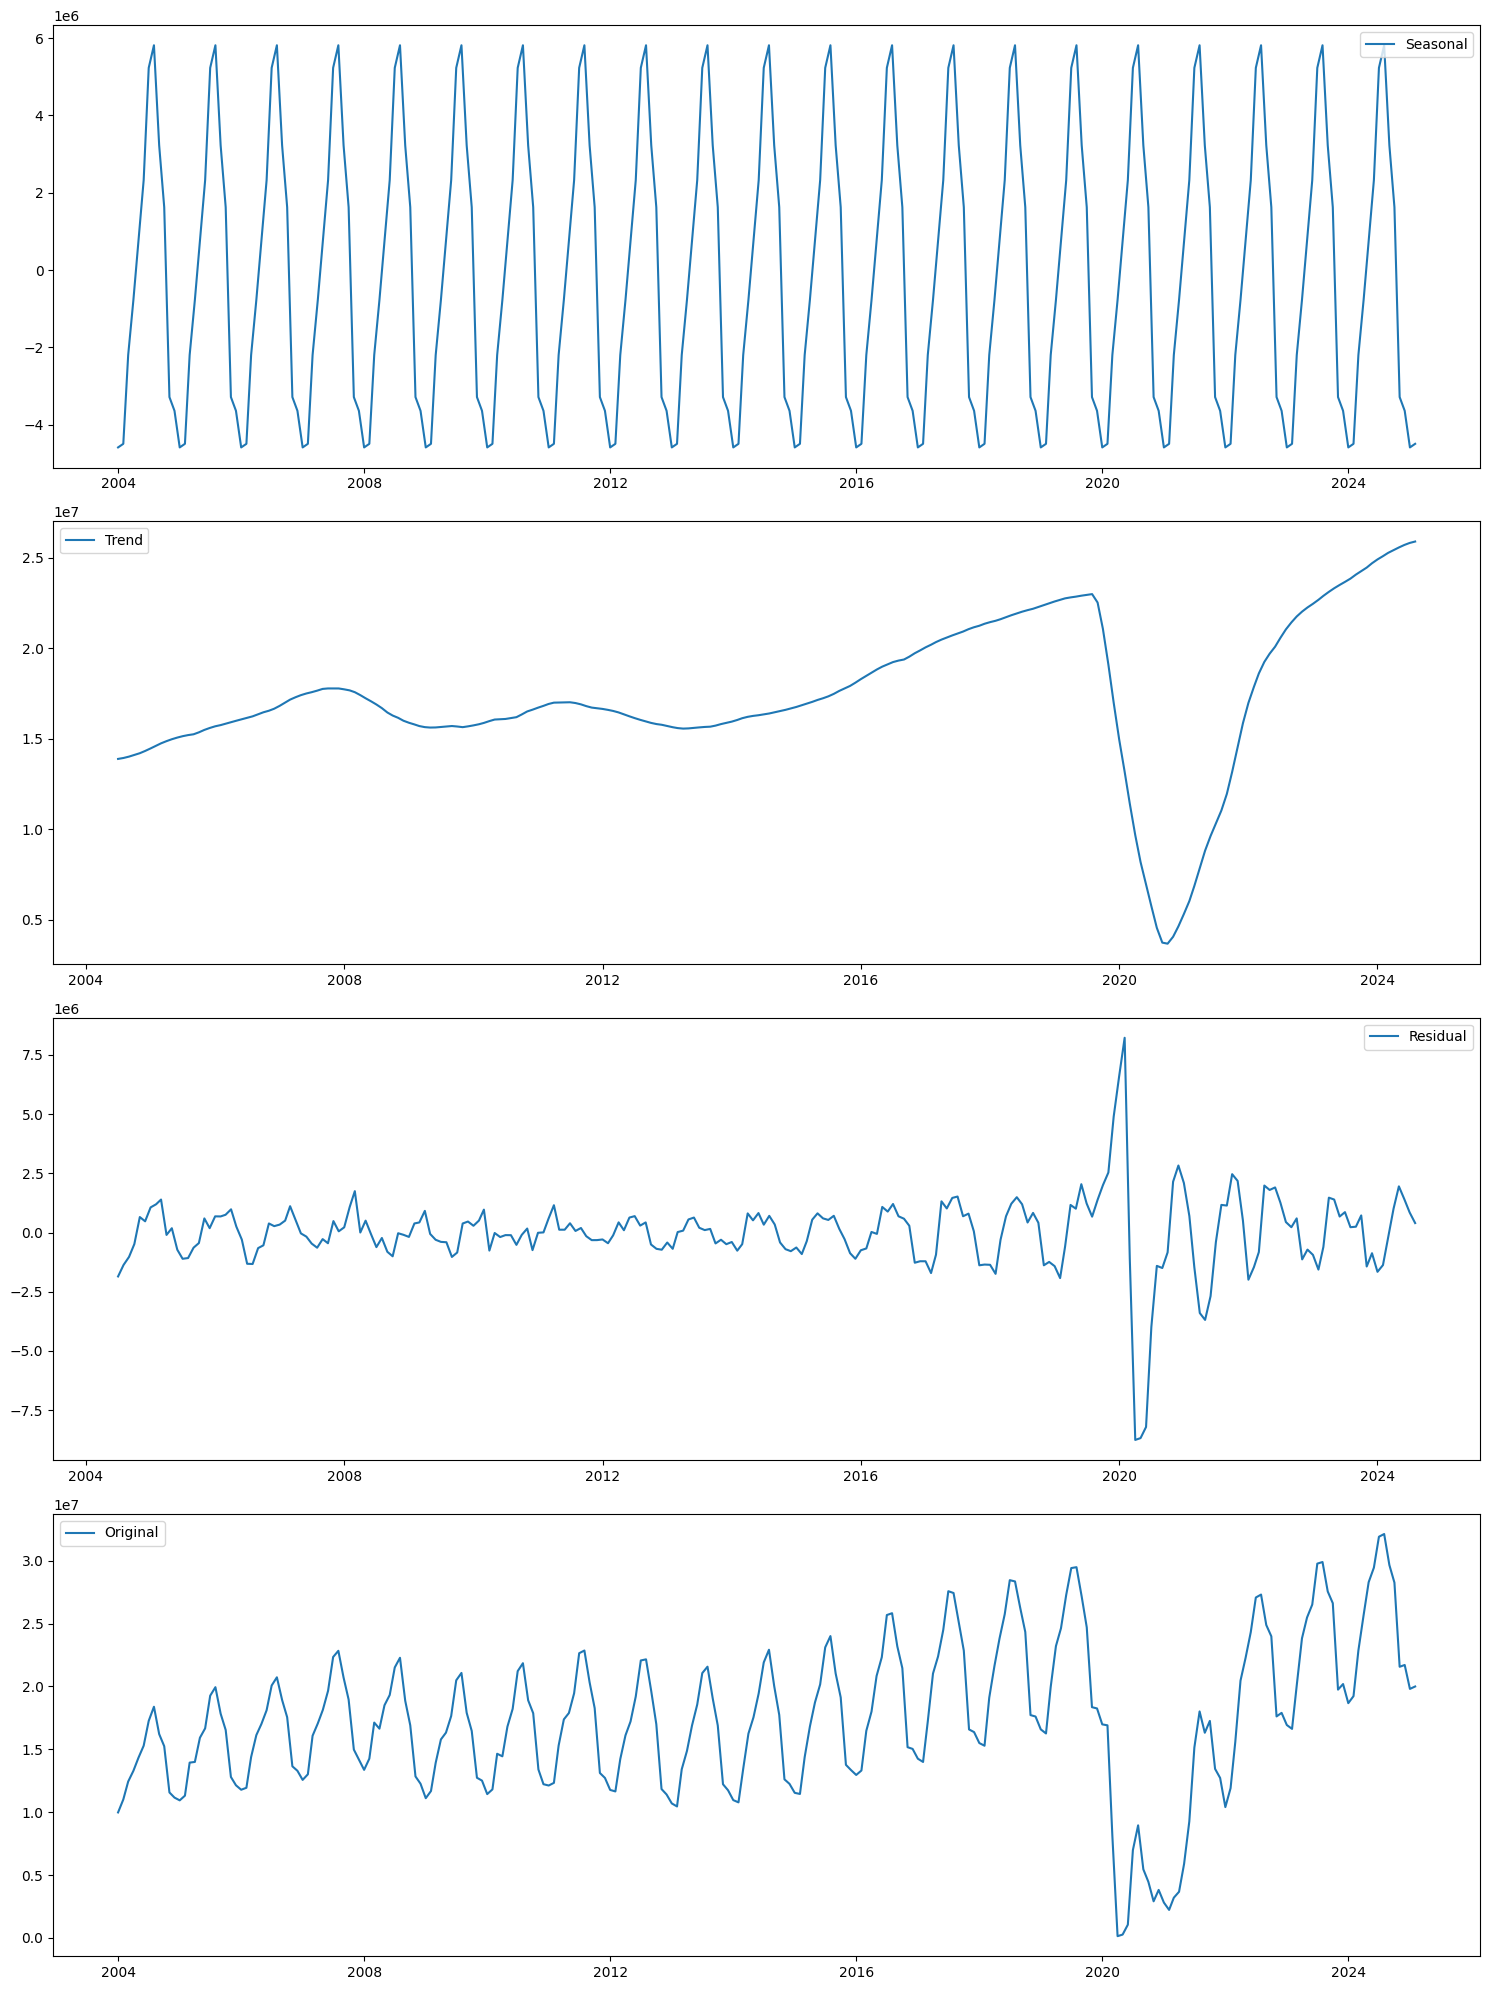

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Create a time series with seasonality

# Decompose the time series
# period = 12 --> mensual
result = seasonal_decompose(ts, period=12)

# Extract the seasonal, trend, and residual components
seasonal = result.seasonal
trend = result.trend
residual = result.resid

# Plot the decomposition
plt.figure(figsize=(15, 20))
plt.subplot(411)

plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(412)

plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)

plt.plot( residual, label='Residual')

plt.legend(loc='best')
plt.subplot(414)

plt.plot( df, label='Original')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


* La primera es la estacionalidad nos aisla el patrón y podemos ver como el patrón se repite constantemente.
* La segunda tendencia, y podemos ver claramente que es al alza salvo un bache que corresponde con la pandemia del Covid19.
* en tercer lugar están los residuos, que si la descomposición se ha realizado bien, deben aparecer aleatorios y con una media constante, como aparecen aquí.
* La última son los datos observados.   

####  3. Modelo ARIMA
ARIMA (Autoregressive Integrated Moving Average) Es uno de los modelos más populares en el análisis de datos temporales porque puede capturar relaciones pasadas para proyectar tendencias futuras y manejar datos no estacionarios al incluir diferenciación.

In [21]:
from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt

# Dividir en train y test
train = ts.iloc[:-12]  # Todas las observaciones excepto las últimas 12
test = ts.iloc[-12:]   # Las últimas 12 observaciones

In [22]:
train

fecha
2004-01-01     9979352
2004-02-01    11008703
2004-03-01    12434592
2004-04-01    13288475
2004-05-01    14325765
                ...   
2023-10-01    26616109
2023-11-01    19743455
2023-12-01    20188071
2024-01-01    18667212
2024-02-01    19226616
Name: num personas, Length: 242, dtype: int64

In [23]:
test

fecha
2024-03-01    22857159
2024-04-01    25669281
2024-05-01    28287870
2024-06-01    29443093
2024-07-01    31900662
2024-08-01    32116068
2024-09-01    29647989
2024-10-01    28251591
2024-11-01    21560768
2024-12-01    21703760
2025-01-01    19801425
2025-02-01    19993427
Name: num personas, dtype: int64

#### 3.1 Diagnóstico aplicando ACF y PACF
Utilizando los graficos de las funciones de autocorrelacion y autocorrelacion parcial tendremos una idea del tipo de modelo ARIMA que mejor encaja con mi serie temporal

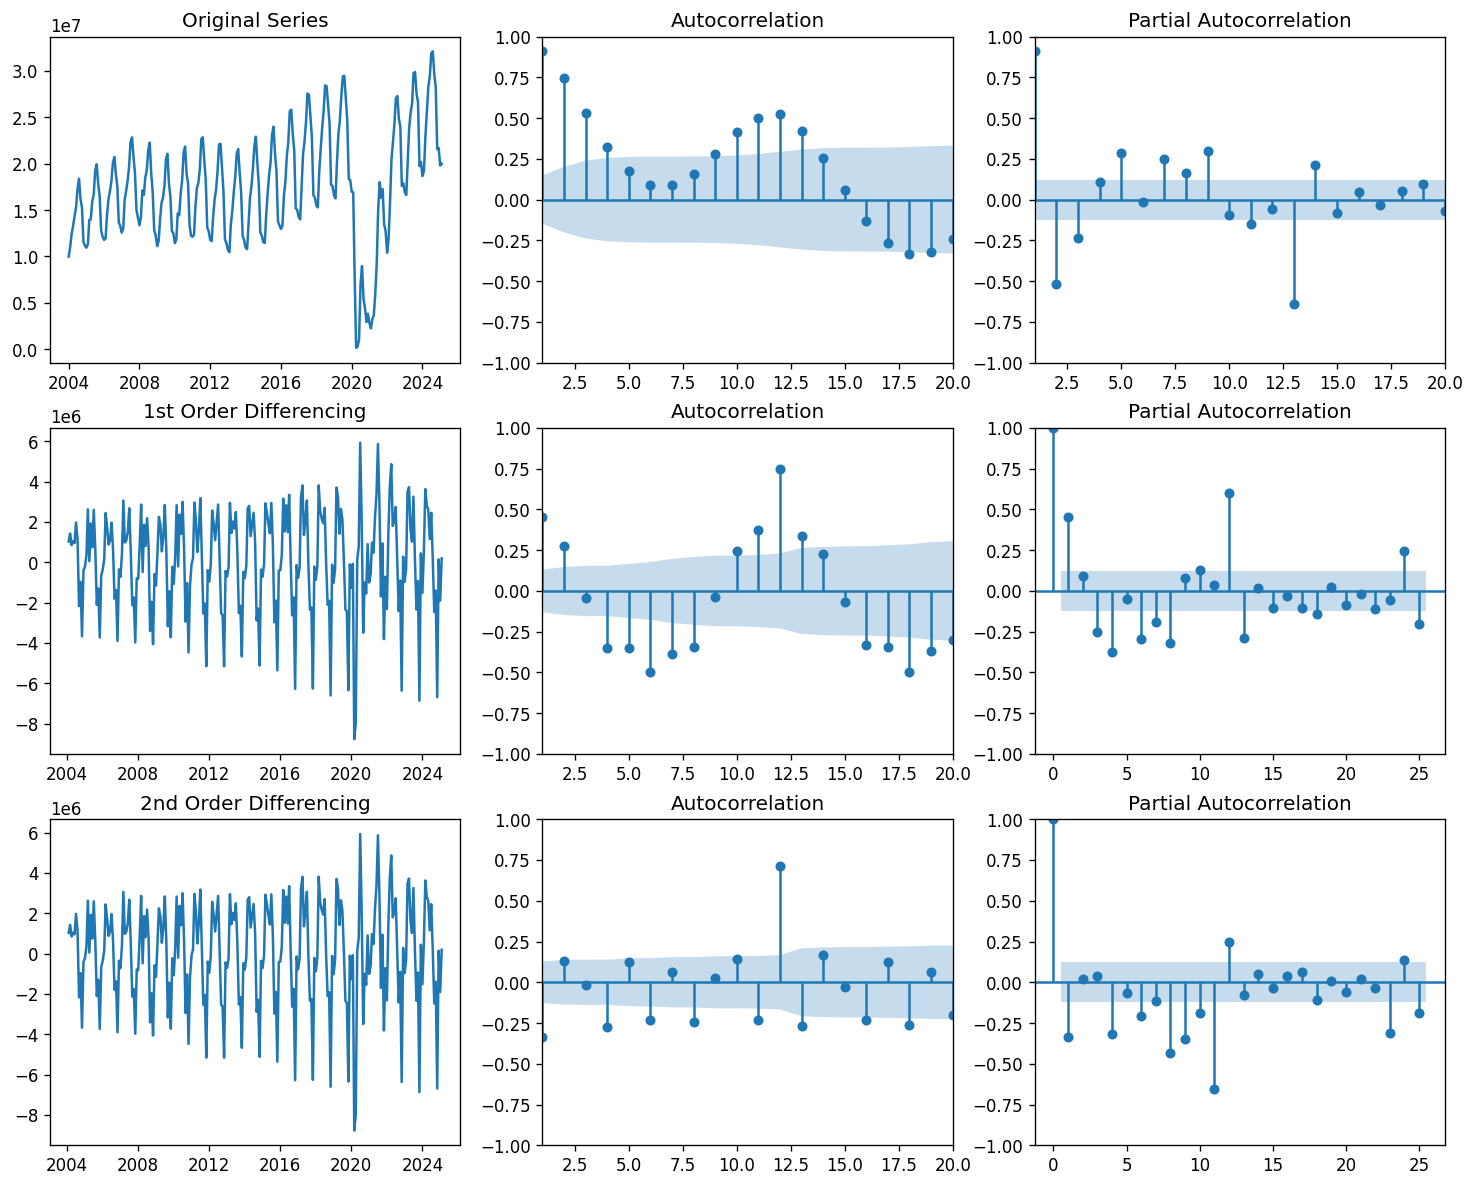

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({'figure.figsize':(15,12), 'figure.dpi':120})


# Original Series
fig, axes = plt.subplots(3, 3)
axes[0, 0].plot(ts); axes[0, 0].set_title('Original Series')
axes[0,1].set_xlim(1, 20)
plot_acf(ts, lags = 20, ax=axes[0, 1])
axes[0,2].set_xlim(1, 20)
plot_pacf(ts,lags = 20, method = "ols", ax=axes[0, 2])

# 1st Differencing

axes[1, 0].plot(ts.diff()); axes[1, 0].set_title('1st Order Differencing')
axes[1,1].set_xlim(1, 20)
plot_acf(ts.diff().dropna(), ax=axes[1, 1])
axes[1,1].set_xlim(1, 20)
plot_pacf(ts.diff().dropna(), method = "ols", ax=axes[1, 2])


axes[2,1].set_xlim(1, 20)
axes[2,1].set_xlim(1, 20)
axes[2, 0].plot(ts.diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(ts.diff().diff().dropna(), ax=axes[2, 1])
plot_pacf(ts.diff().diff().dropna(), method = "ols", ax=axes[2, 2])

plt.show()


#### 3.2 Modelo ARIMA

A la vista del los plot ACF y PACF sugiere un modelo AR 12, diferenciacion 2 y MA 1

In [28]:
model = ARIMA(train, order=(12, 2, 1))

#model = SARIMAX(train, order=(2,2,1), seasonal_order=(1,1,1,12))


model_fit = model.fit()

# Make predictions
predictions = model_fit.predict(start=len(train), end=len(train)+11, dynamic=False)
print(model_fit.summary())

C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Like

                               SARIMAX Results                                
Dep. Variable:           num personas   No. Observations:                  242
Model:                ARIMA(12, 2, 1)   Log Likelihood               -3759.158
Date:                Sat, 21 Mar 2026   AIC                           7546.315
Time:                        07:41:19   BIC                           7595.044
Sample:                    01-01-2004   HQIC                          7565.950
                         - 02-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0944      0.259     -4.232      0.000      -1.601      -0.588
ar.L2         -0.8625      0.188     -4.596      0.000      -1.230      -0.495
ar.L3         -0.8552      0.162     -5.271      0.0

In [294]:
predictions

2024-03-01   22190029.268316
2024-04-01   24732652.596195
2024-05-01   27051373.895158
2024-06-01   28559771.783211
2024-07-01   30861981.279502
2024-08-01   30591391.619584
2024-09-01   29056104.765152
2024-10-01   27813233.530194
2024-11-01   22654481.610721
2024-12-01   22626093.464586
2025-01-01   21144105.439906
2025-02-01   21874808.707550
Freq: MS, Name: predicted_mean, dtype: float64

#### 3.3 Representamos la serie con su predicción

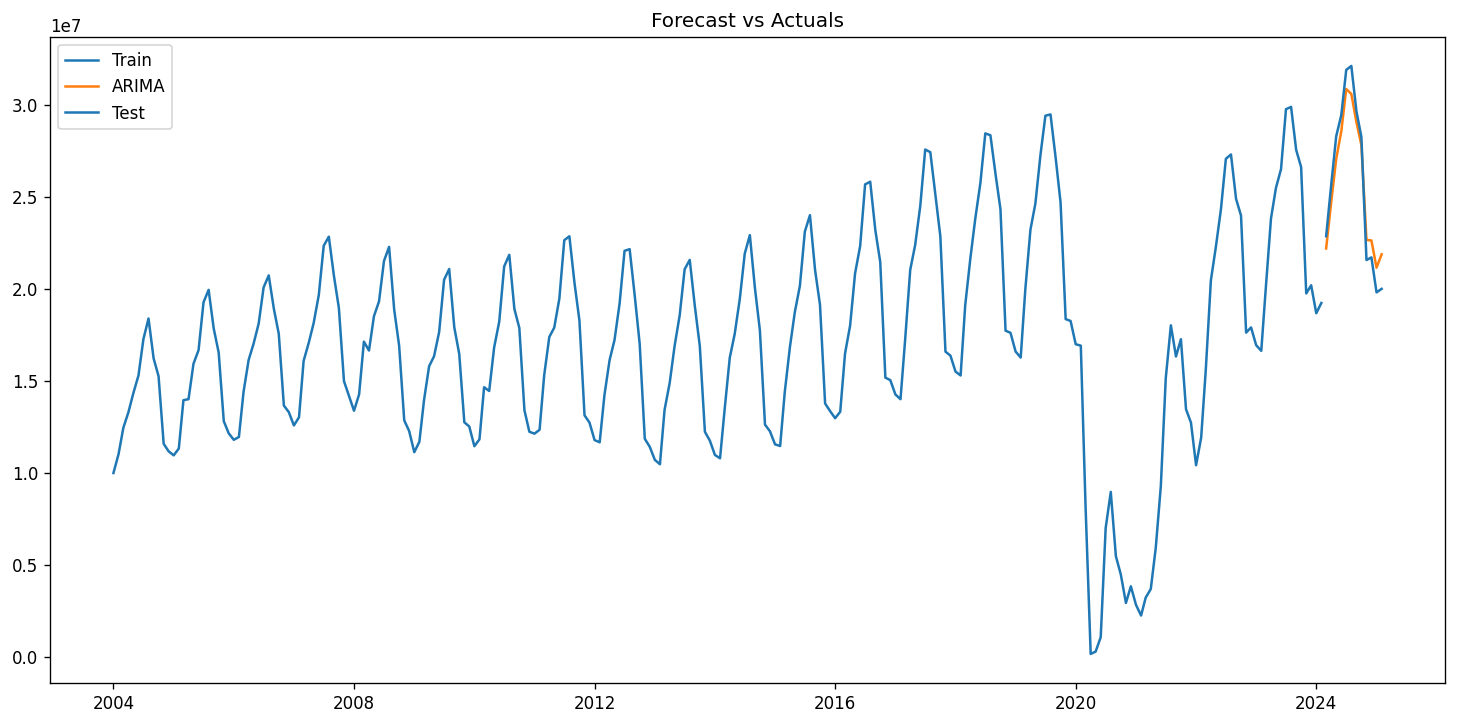

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(test, color=colors[0], label='Test')


plt.title('Forecast vs Actuals')
plt.legend()
plt.show()


#### 3.4 Evaluamos el modelo

##### Plots de residuales

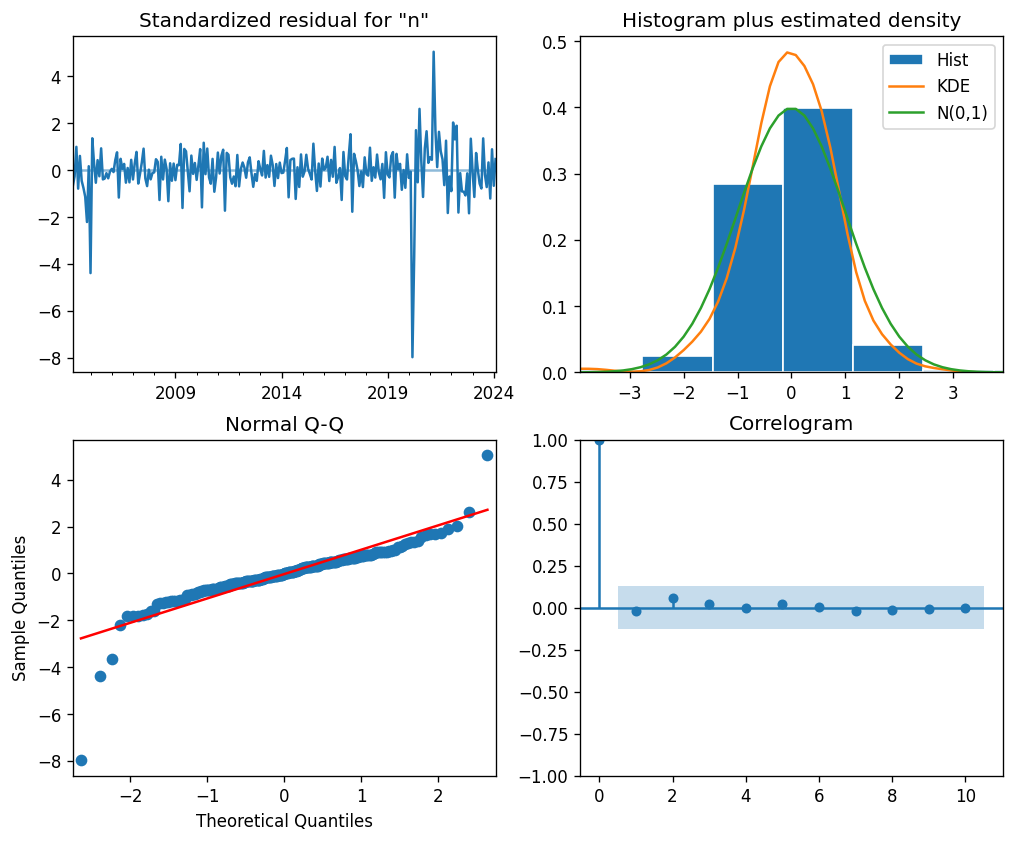

In [30]:
model_fit.plot_diagnostics(figsize=(10,8))
plt.show()

Los residuales son buenos cuando su media es aproximadamente 0 y la varianza uniforme.
además segun la prueba de Ljung-Box su valor es 0.43 que indica que no hay correlacion en los residuos y por tanto son ruido blanco

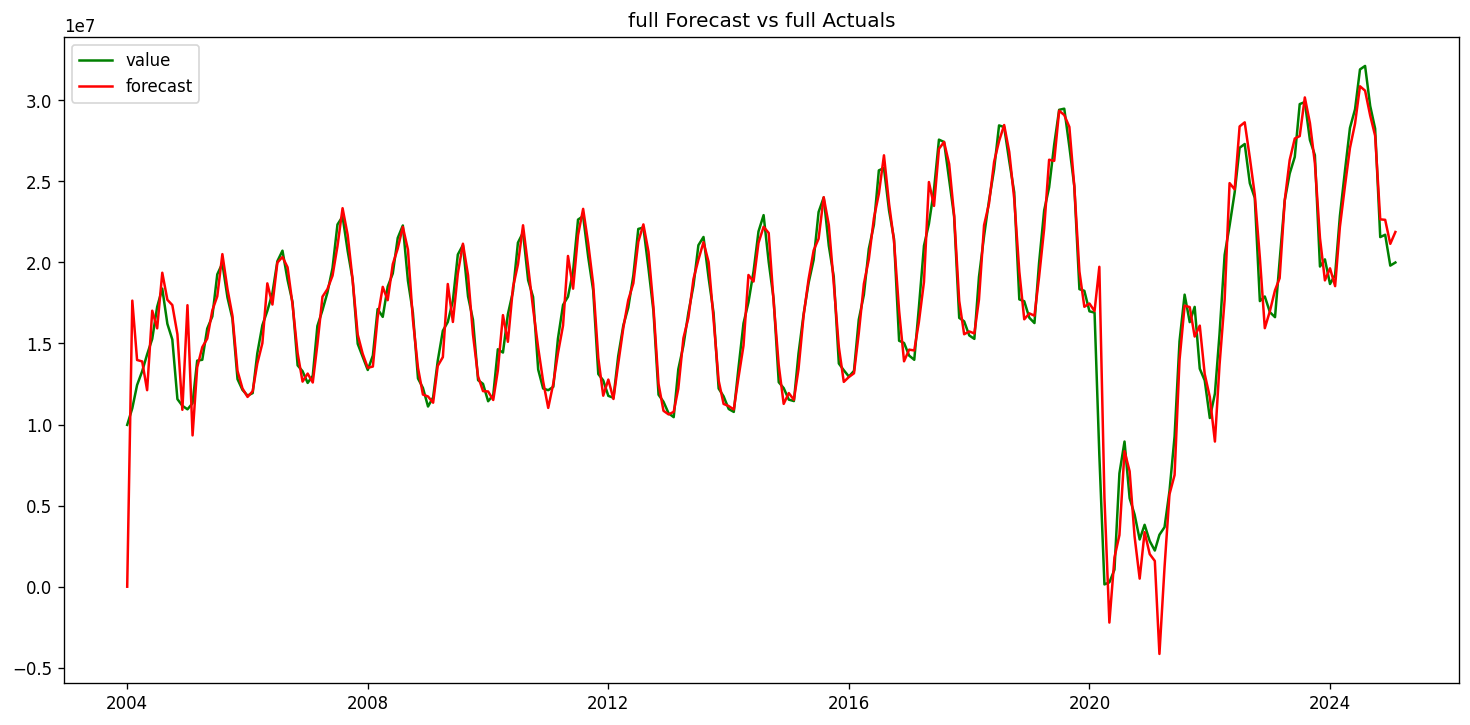

In [31]:
predictions_full = model_fit.predict(start=0, end=len(train)+11, dynamic=False)
# Plot the time series and predictions
plt.figure(figsize=(15, 7))
plt.plot(ts, color='green', label='value')
plt.plot(predictions_full, color='red',  label='forecast')
plt.legend(loc='best')
plt.title('full Forecast vs full Actuals')
plt.show()

#### Accuracy Metrics for Time Series Forecast 

The commonly used accuracy metrics to judge forecasts are:  

Mean Absolute Percentage Error (MAPE)  
Mean Error (ME)  
Mean Absolute Error (MAE)  
Mean Percentage Error (MPE)  
Root Mean Squared Error (RMSE)  
Lag 1 Autocorrelation of Error (ACF1)  
Correlation between the Actual and the Forecast (corr)  
Min-Max Error (minmax)  

Typically, we will use three accuracy metrices:    

MAPE  
Correlation and  
Min-Max Error  
can be used. The above three are percentage errors that vary between 0 and 1. That way, we can judge how good is the forecast irrespective of the scale of the series.

In [32]:
from statsmodels.tsa.stattools import acf
# Accuracy metrics
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(forecast-actual)[1]                      # ACF1
    resultados={'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'acf1':acf1, 
            'corr':corr, 'minmax':minmax}
    pd.options.display.float_format = '{:.6f}'.format #esto es para que lo pinte en formato float
    df = pd.DataFrame(resultados.items(), columns=["Métrica", "Valor"])
    return(df)

forecast_accuracy(predictions.to_numpy(), test.to_numpy())

,Métrica,Valor
0,mape,0.042503
1,me,-173088.753327
2,mae,1046440.290454
3,mpe,0.000019
4,rmse,1116795.644293
5,acf1,0.700502
6,corr,0.987836
7,minmax,0.041121


Un MAPE del 4.46% indica que el modelo es exacto en el 95,54% de las predicciones de las 11 siguientes observaciones

In [33]:
train

fecha
2004-01-01     9979352
2004-02-01    11008703
2004-03-01    12434592
2004-04-01    13288475
2004-05-01    14325765
                ...   
2023-10-01    26616109
2023-11-01    19743455
2023-12-01    20188071
2024-01-01    18667212
2024-02-01    19226616
Name: num personas, Length: 242, dtype: int64

#### 4.  SARIMAX

SARIMAX significa Seasonal AutoRegressive Integrated Moving Average with eXogenous variables. Es un modelo estadístico avanzado para series temporales que:

* Captura patrones estacionales (como ventas que suben en diciembre)
* Ajusta tendencias y fluctuaciones temporales
* Permite incluir variables externas (como inflación, promociones, clima, etc.)
* Modela de manera diferenciada la parte regular y la parte estacional de la serie

#### 4.1 Modelo

In [34]:
#model = ARIMA(train, order=(12, 2, 1))
# order (p, d, q)
# Seasonal order (P, D, Q, s)
# p es autorregresivo
# d es diferendciacion 
#q es la media movil

model = SARIMAX(train, order=(2,2,1), seasonal_order=(1,1,1,12))
results = model.fit()


model_fit = model.fit()

# Make predictions
predictions_SARIMAX = model_fit.predict(start=len(train), end=len(train)+11, dynamic=False)
print(model_fit.summary())

C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\tomas\ML\time_series\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                       num personas   No. Observations:                  242
Model:             SARIMAX(2, 2, 1)x(1, 1, 1, 12)   Log Likelihood               -3555.438
Date:                            Sat, 21 Mar 2026   AIC                           7122.876
Time:                                    07:48:39   BIC                           7143.452
Sample:                                01-01-2004   HQIC                          7131.178
                                     - 02-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4341      0.062      7.042      0.000       0.313       0.555
ar.L2         -0.0691      0.089   

#### 4.2 Representamos la prevision del modelo

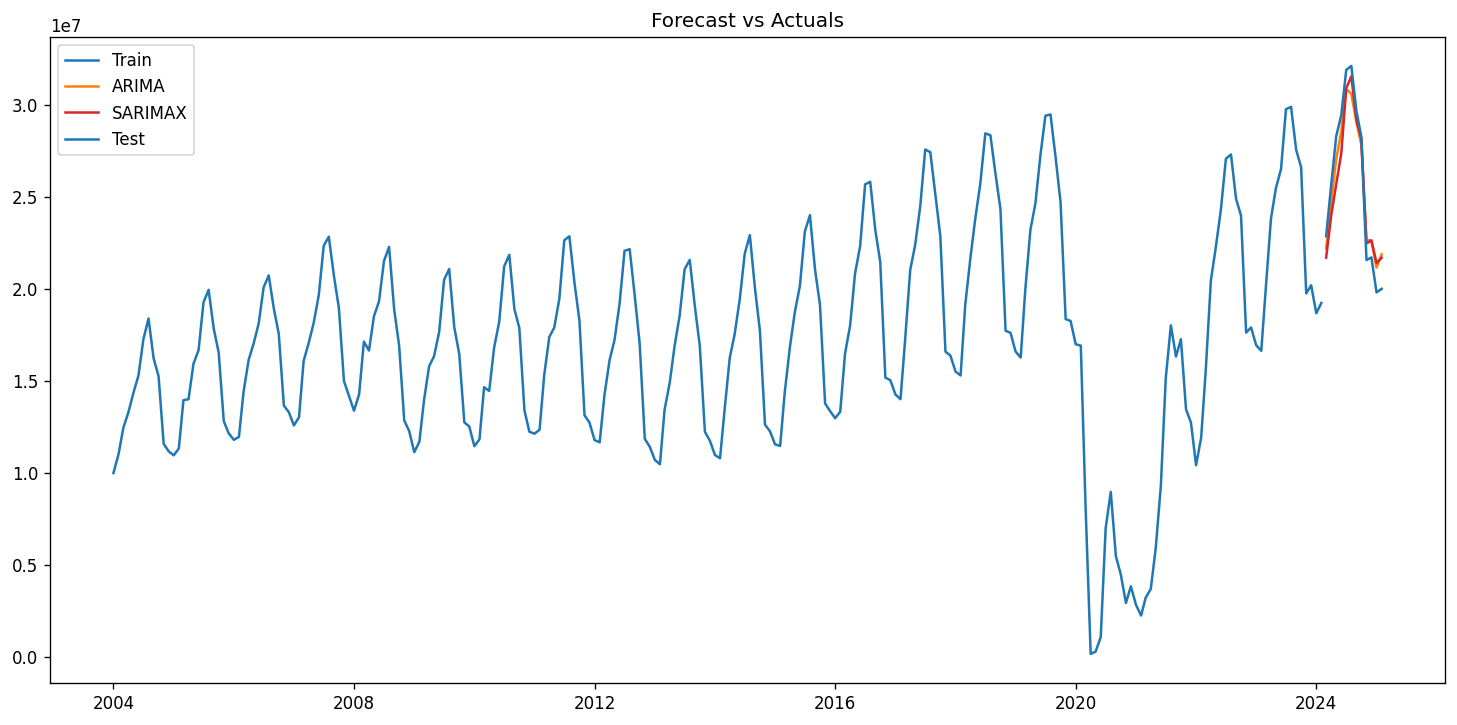

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(test, color=colors[0], label='Test')

plt.title('Forecast vs Actuals')
plt.legend()
plt.show()


#### 4.3 Evaluamos el modelo

##### Plot de residuales

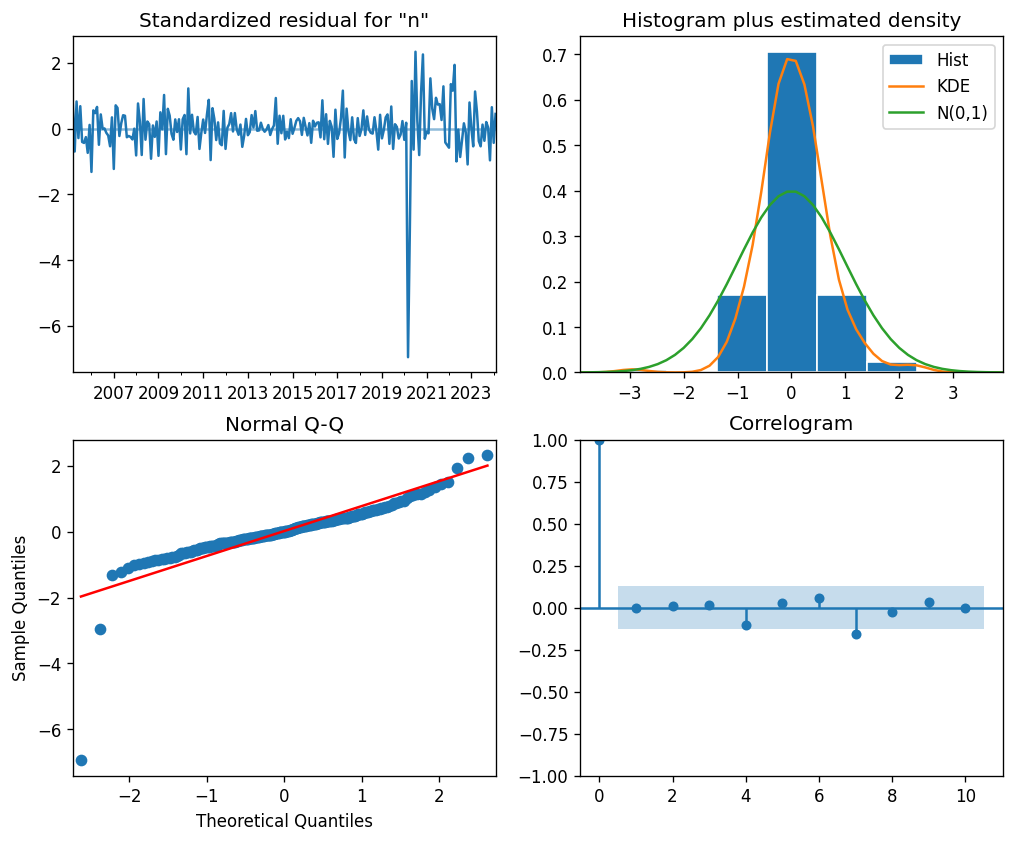

In [36]:
model_fit.plot_diagnostics(figsize=(10,8))
plt.show()

##### Métricas de error

In [37]:
forecast_accuracy(predictions_SARIMAX.to_numpy(), test.to_numpy())

,Métrica,Valor
0,mape,0.049867
1,me,-383249.007077
2,mae,1234822.626312
3,mpe,-0.008297
4,rmse,1413828.463928
5,acf1,0.789320
6,corr,0.960727
7,minmax,0.048533


#### 5. Grid Search

revisar bien

In [39]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from math import sqrt
from sklearn.metrics import mean_squared_error

# Evaluar un modelo SARIMAX para un orden (p,d,q)(P,D,Q,s) dado
def evaluate_sarimax_model(train, test, arima_order, seasonal_order):
    model = SARIMAX(train, order=arima_order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    # Make predictions
    predictions = model_fit.predict(start=len(train), end=(len(train) + len(test) - 1), dynamic=False)
    rmse = sqrt(mean_squared_error(test, predictions))
    return rmse

# Evaluar combinaciones de parámetros para SARIMAX
def evaluate_models(train, test, p_values, d_values, q_values,
                    P_values, D_values, Q_values, s):
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                for P in P_values:
                    for D in D_values:
                        for Q in Q_values:
                            order = (p, d, q)
                            seasonal_order = (P, D, Q, s)
                            try:
                                rmse = evaluate_sarimax_model(train, test, order, seasonal_order)
                                if rmse < best_score:
                                    best_score, best_cfg = rmse, (order, seasonal_order)
                                print('SARIMAX%s x %s RMSE=%.3f' % (order, seasonal_order, rmse))
                            except Exception as e:
                                print(f"Error con el orden {order} x {seasonal_order}: {e}")
                                continue

    return best_cfg, best_score

# Parámetros no estacionales
p_values = range(0, 2)
d_values = range(0, 2)
q_values = range(0, 2)

# Parámetros estacionales
P_values = range(0, 2)
D_values = range(0, 2)
Q_values = range(0, 2)
s = 12  # <- Cambia según tu estacionalidad (12=mensual, 4=trimestral, 7=diaria)

warnings.filterwarnings("ignore")
best_cfg, best_score = evaluate_models(train, test, p_values, d_values, q_values,
                                        P_values, D_values, Q_values, s)
print('Best SARIMAX%s RMSE=%.3f' % (best_cfg, best_score))

SARIMAX(0, 0, 0) x (0, 0, 0, 12) RMSE=26303460.157
SARIMAX(0, 0, 0) x (0, 0, 1, 12) RMSE=9994182.642
SARIMAX(0, 0, 0) x (0, 1, 0, 12) RMSE=2075268.498
SARIMAX(0, 0, 0) x (0, 1, 1, 12) RMSE=4603024.726
SARIMAX(0, 0, 0) x (1, 0, 0, 12) RMSE=2509060.016
SARIMAX(0, 0, 0) x (1, 0, 1, 12) RMSE=2669372.444
SARIMAX(0, 0, 0) x (1, 1, 0, 12) RMSE=2371561.419
SARIMAX(0, 0, 0) x (1, 1, 1, 12) RMSE=4292538.902
SARIMAX(0, 0, 1) x (0, 0, 0, 12) RMSE=25596461.149
SARIMAX(0, 0, 1) x (0, 0, 1, 12) RMSE=10504791.035
SARIMAX(0, 0, 1) x (0, 1, 0, 12) RMSE=1945639.171
SARIMAX(0, 0, 1) x (0, 1, 1, 12) RMSE=5773654.205
SARIMAX(0, 0, 1) x (1, 0, 0, 12) RMSE=2574276.174
SARIMAX(0, 0, 1) x (1, 0, 1, 12) RMSE=2601582.836
SARIMAX(0, 0, 1) x (1, 1, 0, 12) RMSE=2206801.730
SARIMAX(0, 0, 1) x (1, 1, 1, 12) RMSE=4543279.493
SARIMAX(0, 1, 0) x (0, 0, 0, 12) RMSE=8013005.145
SARIMAX(0, 1, 0) x (0, 0, 1, 12) RMSE=3688884.485
SARIMAX(0, 1, 0) x (0, 1, 0, 12) RMSE=896647.607
SARIMAX(0, 1, 0) x (0, 1, 1, 12) RMSE=1622564.22

In [ ]:
model = SARIMAX(train, order=(2,2,1), seasonal_order=(1,1,1,12))
results = model.fit()


model_fit = model.fit()

# Make predictions
predictions_SARIMAX = model_fit.predict(start=len(train), end=len(train)+11, dynamic=False)
print(model_fit.summary())

In [44]:
best_cfg[1]

(1, 1, 0, 12)

In [45]:
#model = ARIMA(train, order=best_cfg)
model = SARIMAX(train, order = best_cfg[0], seasonal_order=best_cfg[1])


model_fit = model.fit()

# Make predictions
predictions_GS = model_fit.predict(start=len(train), end=len(train)+11, dynamic=False)
print(model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        num personas   No. Observations:                  242
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood               -3608.493
Date:                             Sat, 21 Mar 2026   AIC                           7224.987
Time:                                     08:01:04   BIC                           7238.739
Sample:                                 01-01-2004   HQIC                          7230.534
                                      - 02-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9172      0.018     49.772      0.000       0.881       0.953
ma.L1          0.3866      

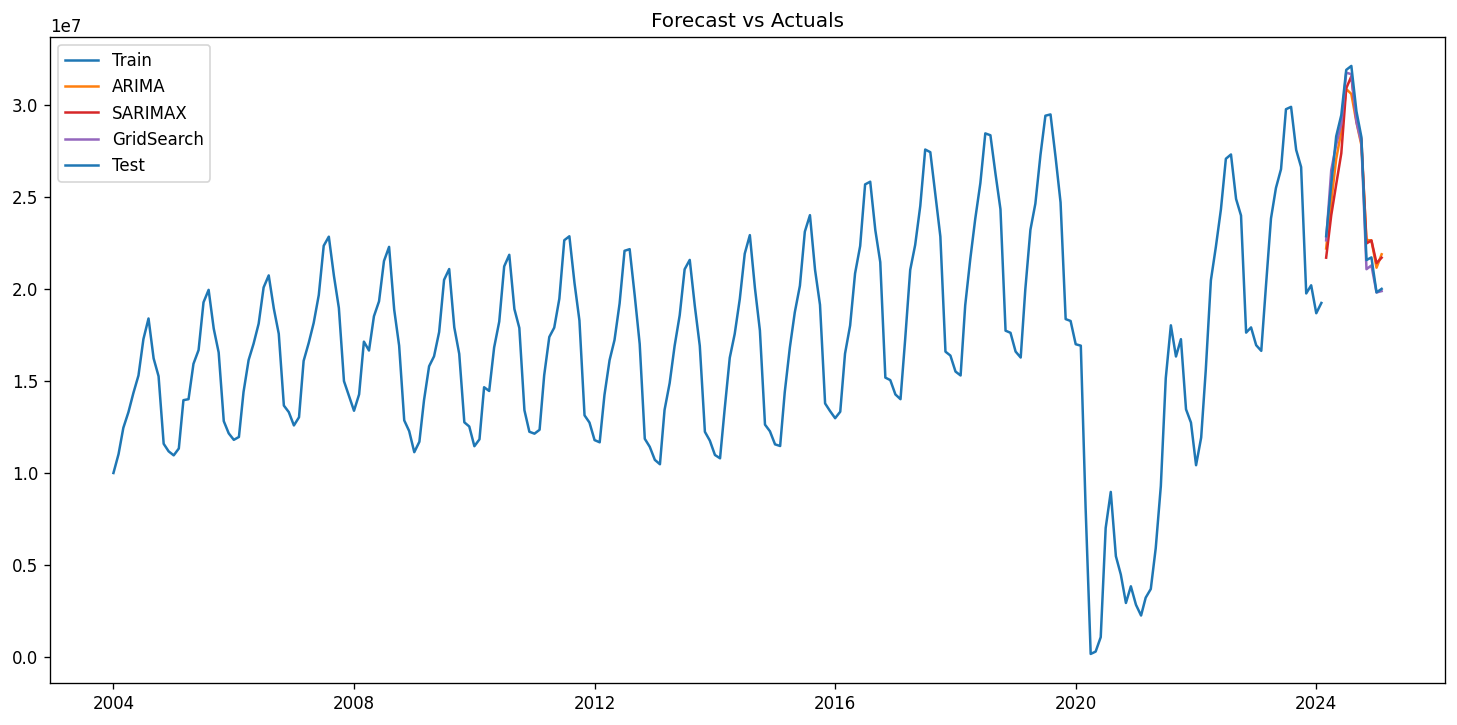

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(predictions_GS, color=colors[4], label='GridSearch')
plt.plot(test, color=colors[0], label='Test')

plt.title('Forecast vs Actuals')
plt.legend()
plt.show()



In [47]:

forecast_accuracy(predictions_GS.to_numpy(), test.to_numpy())

,Métrica,Valor
0,mape,0.014282
1,me,-244559.634728
2,mae,374299.361432
3,mpe,-0.009228
4,rmse,428835.747534
5,acf1,-0.027995
6,corr,0.996826
7,minmax,0.014208


#### 6. PMDARIMA 

El modelo auto_arima de la librería pmdarima busca minimizar una métrica de información estadística, no directamente una métrica de error como RMSE o MAE. Por defecto, la métrica que se minimiza es el Akaike Information Criterion (AIC).  
Es una medida que evalúa qué tan bien se ajusta el modelo a los datos, penalizando la complejidad del modelo.

Cuanto menor sea el AIC, mejor es el equilibrio entre ajuste y simplicidad.

Fórmula simplificada: $$AIC = 2k - 2\ln(L)$$ donde 
𝑘
 es el número de parámetros y 
𝐿
 es la verosimilitud del modelo.


requiere version de Numpy<2.0

In [48]:
from statsmodels.tsa.arima_model import ARIMA

import pmdarima as pm

model = pm.auto_arima(train, start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=12, max_q=12, # maximum p and q
                      m=12,              # frecuencia de la estacionalidad: cada 12 meses
                      d=None,           # let model determine 'd' --> diferenciacion de la serie
                      seasonal=True,   # Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=7658.942, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=7782.954, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=7617.120, Time=0.12 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=7669.314, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=7781.015, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=7730.216, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=7610.997, Time=0.40 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=7601.191, Time=0.41 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=7599.561, Time=0.26 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=7656.481, Time=0.13 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=7600.876, Time=0.61 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=7636.363, Time=0.30 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=7602.242, Time=0.83 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=7649.109, Time=0.18 sec
 ARIMA(2,1,0)(1,0,1

ARIMA(4,1,2)(2,0,0)[12] intercept   : AIC=7580.815, Time=3.77  
La parte estacional autoregresiva (SAR) de orden 2 indica que la serie se basa en valores de 12 y 24 meses atrás.

In [49]:
predictions_pmd = model.predict(12)

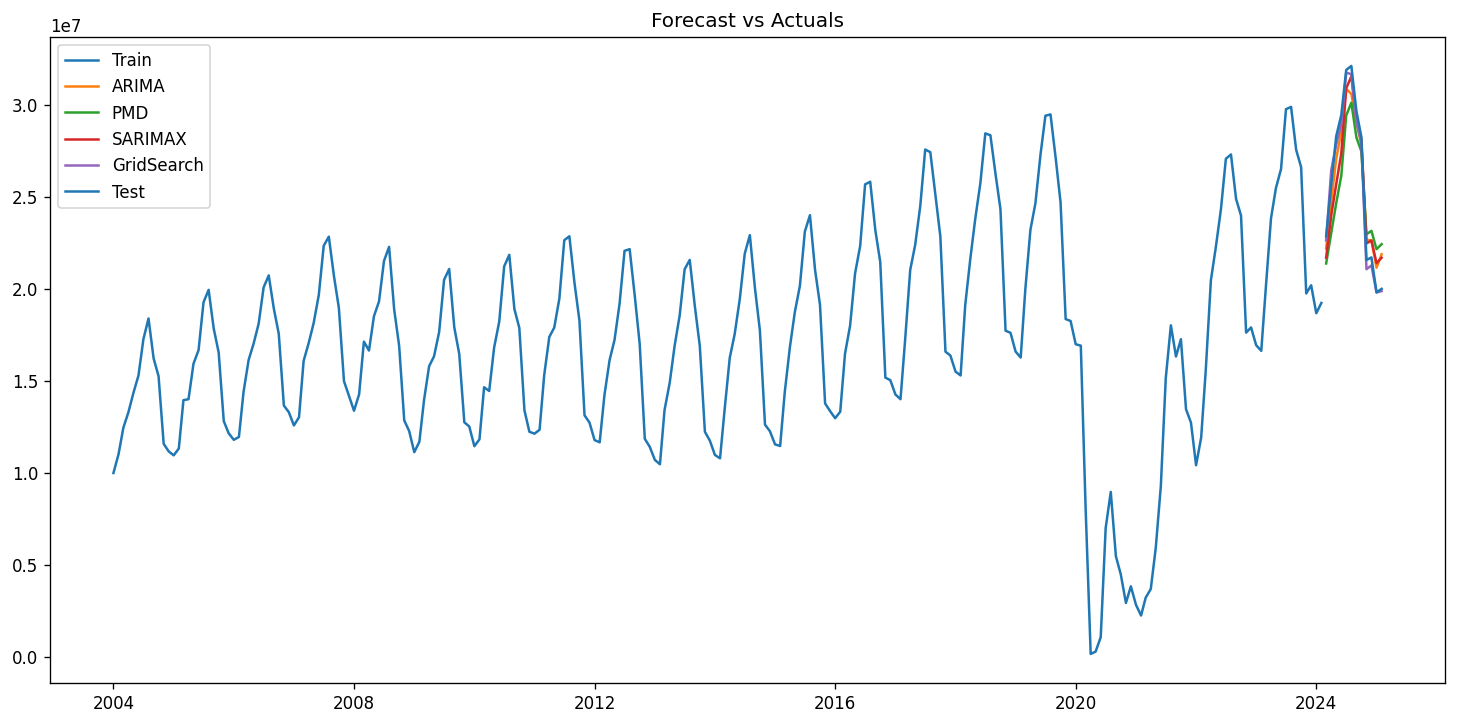

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_pmd, color=colors[2], label='PMD')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(predictions_GS, color=colors[4], label='GridSearch')
plt.plot(test, color=colors[0], label='Test')

plt.title('Forecast vs Actuals')
plt.legend()
plt.show()




#### Plots de residuales

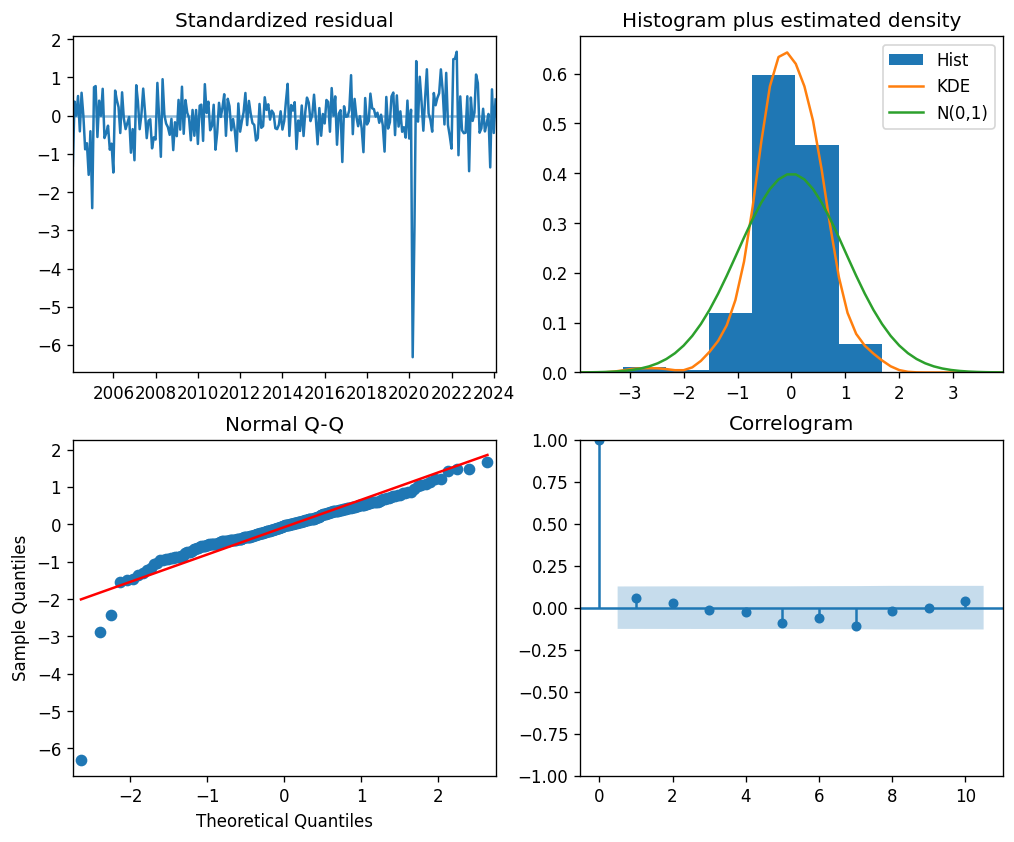

In [51]:
model.plot_diagnostics(figsize=(10,8))
plt.show()

In [52]:
forecast_accuracy(predictions_pmd.to_numpy(), test.to_numpy())

,Métrica,Valor
0,mape,0.082966
1,me,-843620.884345
2,mae,2113787.288019
3,mpe,-0.021044
4,rmse,2264077.734376
5,acf1,0.803370
6,corr,0.910129
7,minmax,0.080146


#### 6.1 Alternativa con StatsForecast y autoarima 

Automatically selects the best ARIMA (AutoRegressive Integrated Moving Average) model using an information criterion. Default is Akaike Information Criterion (AICc).  
https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html  

In [53]:
%pip install StatsForecast

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\tomas\ML\time_series\Scripts\python.exe -m pip install --upgrade pip


In [54]:
df

,num personas
fecha,
2004-01-01,9979352
2004-02-01,11008703
2004-03-01,12434592
2004-04-01,13288475
2004-05-01,14325765
...,...
2024-10-01,28251591
2024-11-01,21560768
2024-12-01,21703760


In [56]:
import pandas as pd

df_train = pd.DataFrame({
    'unique_id': 'serie1',
    'ds': train.index,
    'y': train.values
})


In [316]:
train

fecha
2004-01-01     9979352
2004-02-01    11008703
2004-03-01    12434592
2004-04-01    13288475
2004-05-01    14325765
                ...   
2023-10-01    26616109
2023-11-01    19743455
2023-12-01    20188071
2024-01-01    18667212
2024-02-01    19226616
Name: num personas, Length: 242, dtype: int64

In [57]:
df_train

,unique_id,ds,y
0,serie1,2004-01-01,9979352
1,serie1,2004-02-01,11008703
2,serie1,2004-03-01,12434592
3,serie1,2004-04-01,13288475
4,serie1,2004-05-01,14325765
...,...,...,...
237,serie1,2023-10-01,26616109
238,serie1,2023-11-01,19743455
239,serie1,2023-12-01,20188071
240,serie1,2024-01-01,18667212


In [58]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

sf = StatsForecast(
    models=[AutoARIMA(
        season_length=12,
        max_p=12,
        max_q=12,
        max_P=12,
        max_Q=12,
        max_d=0,
        max_D=0,
    )],
    freq='M'
)

sf = sf.fit(df_train)



predictions_auto = sf.predict(h=12)
predictions_auto

,unique_id,ds,AutoARIMA
0,serie1,2024-02-29,22000070.000000
1,serie1,2024-03-31,25076394.000000
2,serie1,2024-04-30,26112564.000000
3,serie1,2024-05-31,26886996.000000
4,serie1,2024-06-30,29051836.000000
5,serie1,2024-07-31,28875160.000000
6,serie1,2024-08-31,26665016.000000
7,serie1,2024-09-30,25669786.000000
8,serie1,2024-10-31,19998988.000000
9,serie1,2024-11-30,20128610.000000


In [61]:
from pandas.tseries.offsets import MonthBegin

pred = predictions_auto.copy()
pred['ds'] = pred['ds'] + MonthBegin(1)   # 29/02 → 01/03, 31/03 → 01/04, etc.
pred = pred.set_index('ds')
pred

,unique_id,AutoARIMA
ds,,
2024-03-01,serie1,22000070.000000
2024-04-01,serie1,25076394.000000
2024-05-01,serie1,26112564.000000
2024-06-01,serie1,26886996.000000
2024-07-01,serie1,29051836.000000
2024-08-01,serie1,28875160.000000
2024-09-01,serie1,26665016.000000
2024-10-01,serie1,25669786.000000
2024-11-01,serie1,19998988.000000


In [62]:

#sf.fitted_[0]
sf.fitted_[0][0].__dict__


{'d': None,
 'D': None,
 'max_p': 12,
 'max_q': 12,
 'max_P': 12,
 'max_Q': 12,
 'max_order': 5,
 'max_d': 0,
 'max_D': 0,
 'start_p': 2,
 'start_q': 2,
 'start_P': 1,
 'start_Q': 1,
 'stationary': False,
 'seasonal': True,
 'ic': 'aicc',
 'stepwise': True,
 'nmodels': 94,
 'trace': False,
 'approximation': False,
 'method': None,
 'truncate': None,
 'test': 'kpss',
 'test_kwargs': None,
 'seasonal_test': 'seas',
 'seasonal_test_kwargs': None,
 'allowdrift': True,
 'allowmean': True,
 'blambda': None,
 'biasadj': False,
 'season_length': 12,
 'alias': 'AutoARIMA',
 'prediction_intervals': None,
 'model_': {'coef': {'ar1': 1.3960742693991322,
   'ar2': -0.45943658232256335,
   'sar1': 0.5250972197072203,
   'sar2': 0.2902070151419303,
   'intercept': 16959948.921487603},
  'sigma2': 1889240347852.31,
  'var_coef': array([[ 0.00320518, -0.00277136, -0.00120206,  0.00195787,  0.        ],
         [-0.00277136,  0.00244018,  0.00129841, -0.00204422,  0.        ],
         [-0.00120206,  0

In [63]:
best = sf.fitted_[0][0]          # AutoARIMA entrenado
arma = best.model_['arma']       # tupla con los órdenes
print(arma)
# (p, d, q, P, D, Q, m) no es así
#(p, q, P, Q, m, d, D)

(2, 0, 2, 0, 12, 0, 0)


ARIMA(p,d,q) = ARIMA(1, 3, 3)  
SARIMA(P,D,Q)[m] = (1, 12, 0)[1]

In [64]:
test

fecha
2024-03-01    22857159
2024-04-01    25669281
2024-05-01    28287870
2024-06-01    29443093
2024-07-01    31900662
2024-08-01    32116068
2024-09-01    29647989
2024-10-01    28251591
2024-11-01    21560768
2024-12-01    21703760
2025-01-01    19801425
2025-02-01    19993427
Name: num personas, dtype: int64

In [65]:
pred['AutoARIMA'].astype('int64')

ds
2024-03-01    22000070
2024-04-01    25076394
2024-05-01    26112564
2024-06-01    26886996
2024-07-01    29051836
2024-08-01    28875160
2024-09-01    26665016
2024-10-01    25669786
2024-11-01    19998988
2024-12-01    20128610
2025-01-01    18887678
2025-02-01    18951882
Name: AutoARIMA, dtype: int64

In [66]:
forecast_accuracy(pred['AutoARIMA'].astype('int64').to_numpy(), test.to_numpy())


,Métrica,Valor
0,mape,0.070815
1,me,-1910676.083333
2,mae,1910676.083333
3,mpe,-0.070815
4,rmse,2109005.446752
5,acf1,0.657895
6,corr,0.991834
7,minmax,0.070815


In [67]:
predictions

2024-03-01   22190029.268316
2024-04-01   24732652.596195
2024-05-01   27051373.895158
2024-06-01   28559771.783211
2024-07-01   30861981.279502
2024-08-01   30591391.619584
2024-09-01   29056104.765152
2024-10-01   27813233.530194
2024-11-01   22654481.610721
2024-12-01   22626093.464586
2025-01-01   21144105.439906
2025-02-01   21874808.707550
Freq: MS, Name: predicted_mean, dtype: float64

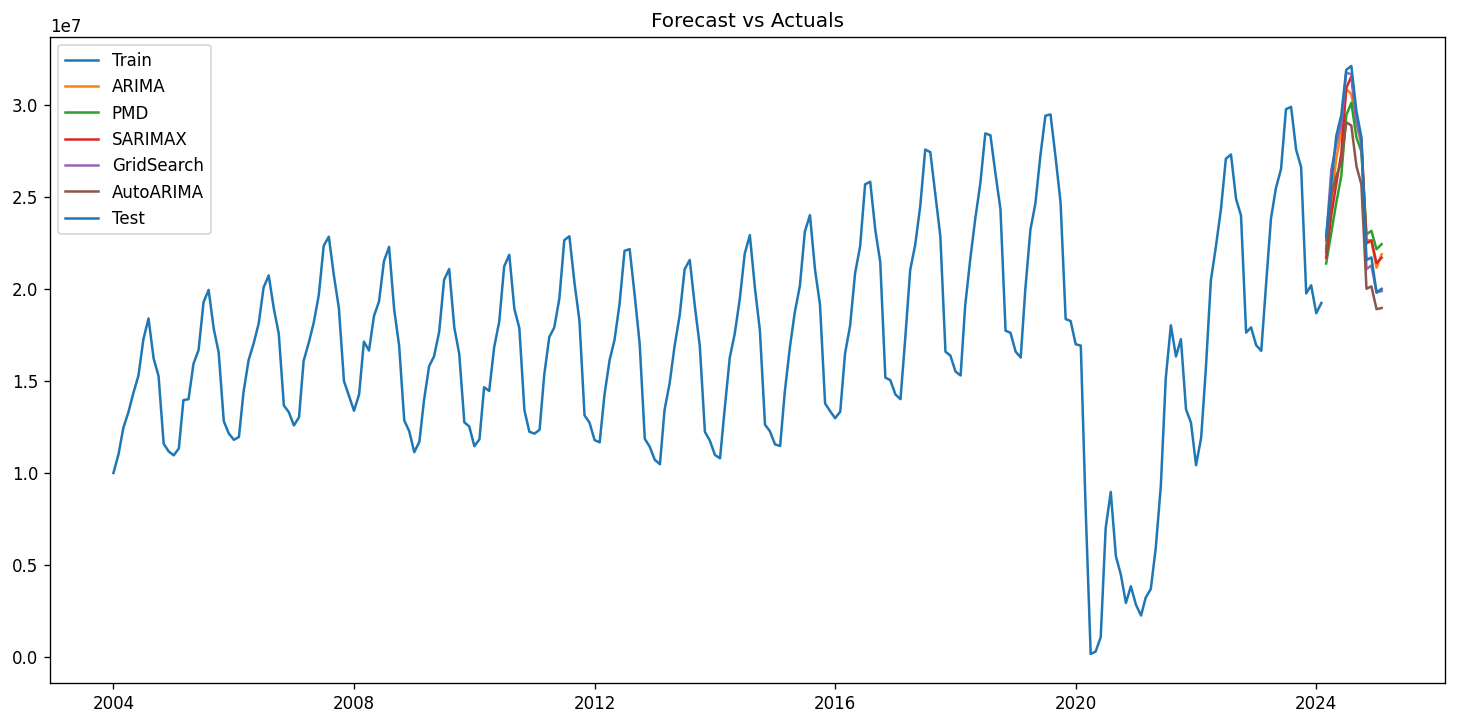

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_pmd, color=colors[2], label='PMD')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(predictions_GS, color=colors[4], label='GridSearch')
plt.plot(pred['AutoARIMA'], color=colors[5], label='AutoARIMA')
plt.plot(test, color=colors[0], label='Test')
plt.title('Forecast vs Actuals')
plt.legend()
plt.show()


#### 7. Previsión de series temporales con Prophet
Prophet es una biblioteca de Python de código abierto desarrollada por Facebook

In [69]:
from prophet import Prophet

In [70]:
df

,num personas
fecha,
2004-01-01,9979352
2004-02-01,11008703
2004-03-01,12434592
2004-04-01,13288475
2004-05-01,14325765
...,...
2024-10-01,28251591
2024-11-01,21560768
2024-12-01,21703760


#### 7.1 Forecast con Prophet

In [71]:
import pandas as pd

dfp = pd.DataFrame({
    'ds': df.index,
    'y': df['num personas'].astype(float) 
})
dfp



,ds,y
fecha,,
2004-01-01,2004-01-01,9979352.000000
2004-02-01,2004-02-01,11008703.000000
2004-03-01,2004-03-01,12434592.000000
2004-04-01,2004-04-01,13288475.000000
2004-05-01,2004-05-01,14325765.000000
...,...,...
2024-10-01,2024-10-01,28251591.000000
2024-11-01,2024-11-01,21560768.000000
2024-12-01,2024-12-01,21703760.000000


In [72]:
train_prp = dfp.iloc[:-12]  # Todas las observaciones excepto las últimas 12
test_prp = dfp.iloc[-12:]   # Las últimas 12 observaciones

In [73]:
train_prp = train_prp.rename(columns={'fecha':'ds' , 'num personas':'y'})
test_prp = test_prp.rename(columns={'fecha':'ds' , 'num personas':'y'})

In [74]:
test_prp

,ds,y
fecha,,
2024-03-01,2024-03-01,22857159.000000
2024-04-01,2024-04-01,25669281.000000
2024-05-01,2024-05-01,28287870.000000
2024-06-01,2024-06-01,29443093.000000
2024-07-01,2024-07-01,31900662.000000
2024-08-01,2024-08-01,32116068.000000
2024-09-01,2024-09-01,29647989.000000
2024-10-01,2024-10-01,28251591.000000
2024-11-01,2024-11-01,21560768.000000


In [75]:
# Crear y entrenar el modelo
model_prp = Prophet()
model_prp.fit(train_prp)

# Generar fechas futuras para predicción
futuro = model_prp.make_future_dataframe(periods=12, freq='MS')  # Predicción para 12 meses adicionales

# Hacer predicciones
predictions_prp = model_prp.predict(futuro)

08:06:23 - cmdstanpy - INFO - Chain [1] start processing
08:06:24 - cmdstanpy - INFO - Chain [1] done processing


In [76]:
futuro

,ds
0,2004-01-01
1,2004-02-01
2,2004-03-01
3,2004-04-01
4,2004-05-01
...,...
249,2024-10-01
250,2024-11-01
251,2024-12-01
252,2025-01-01


In [77]:
predictions_prp

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2004-01-01,15255261.063518,5077262.560511,16644833.770218,15255261.063518,15255261.063518,-4438341.522410,-4438341.522410,-4438341.522410,-4438341.522410,-4438341.522410,-4438341.522410,0.000000,0.000000,0.000000,10816919.541108
1,2004-02-01,15270530.782192,5196952.086577,16444624.523219,15270530.782192,15270530.782192,-4276893.761491,-4276893.761491,-4276893.761491,-4276893.761491,-4276893.761491,-4276893.761491,0.000000,0.000000,0.000000,10993637.020701
2,2004-03-01,15284815.357726,7578900.345830,18812609.028434,15284815.357726,15284815.357726,-2189716.618452,-2189716.618452,-2189716.618452,-2189716.618452,-2189716.618452,-2189716.618452,0.000000,0.000000,0.000000,13095098.739274
3,2004-04-01,15300085.076399,9013595.958155,19988148.742097,15300085.076399,15300085.076399,-940982.485403,-940982.485403,-940982.485403,-940982.485403,-940982.485403,-940982.485403,0.000000,0.000000,0.000000,14359102.590997
4,2004-05-01,15314862.223503,10731051.189055,21896630.593128,15314862.223503,15314862.223503,553203.743348,553203.743348,553203.743348,553203.743348,553203.743348,553203.743348,0.000000,0.000000,0.000000,15868065.966851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-10-01,18942407.291257,15056857.111773,26223516.548429,18942363.850797,18942451.104155,1601459.071674,1601459.071674,1601459.071674,1601459.071674,1601459.071674,1601459.071674,0.000000,0.000000,0.000000,20543866.362931
250,2024-11-01,18957454.399572,9922985.715065,21750236.763316,18957395.325785,18957511.638677,-3238657.385619,-3238657.385619,-3238657.385619,-3238657.385619,-3238657.385619,-3238657.385619,0.000000,0.000000,0.000000,15718797.013953
251,2024-12-01,18972016.117296,9745766.184000,21442561.690106,18971944.171075,18972086.306753,-3605093.180277,-3605093.180277,-3605093.180277,-3605093.180277,-3605093.180277,-3605093.180277,0.000000,0.000000,0.000000,15366922.937019
252,2025-01-01,18987063.225611,8706399.136006,20481376.856336,18986981.813085,18987147.996155,-4540910.152985,-4540910.152985,-4540910.152985,-4540910.152985,-4540910.152985,-4540910.152985,0.000000,0.000000,0.000000,14446153.072627


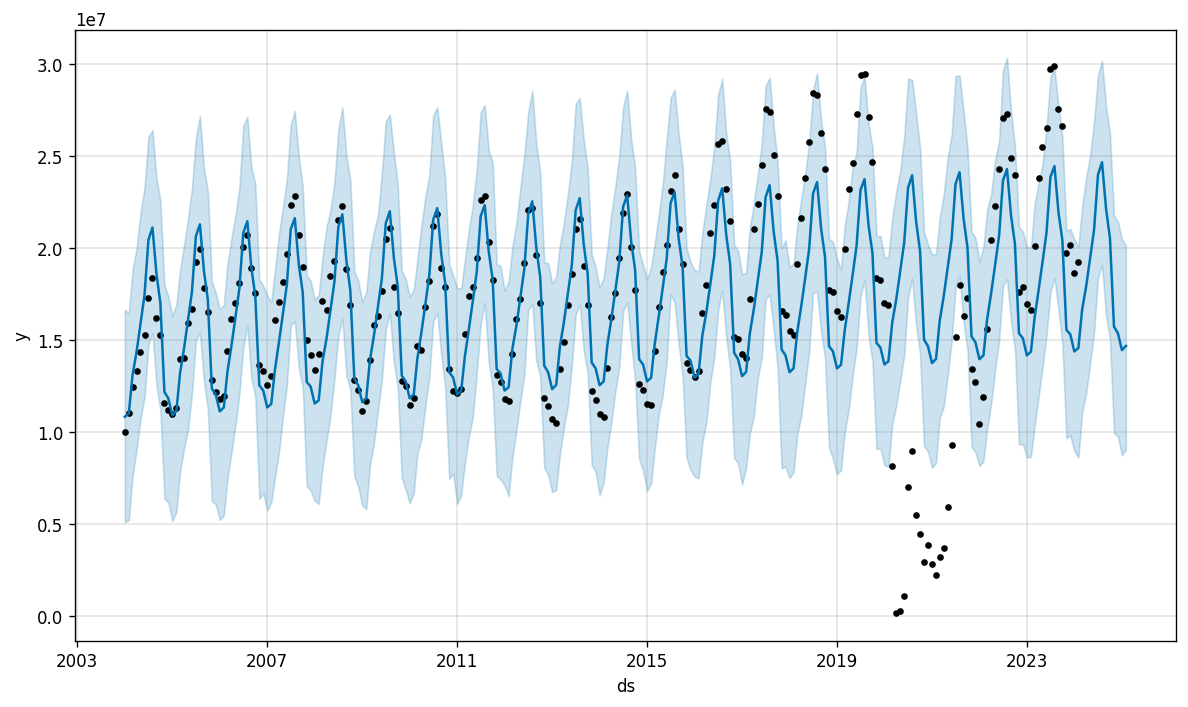

In [78]:
# Graficar resultados
model_prp.plot(predictions_prp)
plt.show()

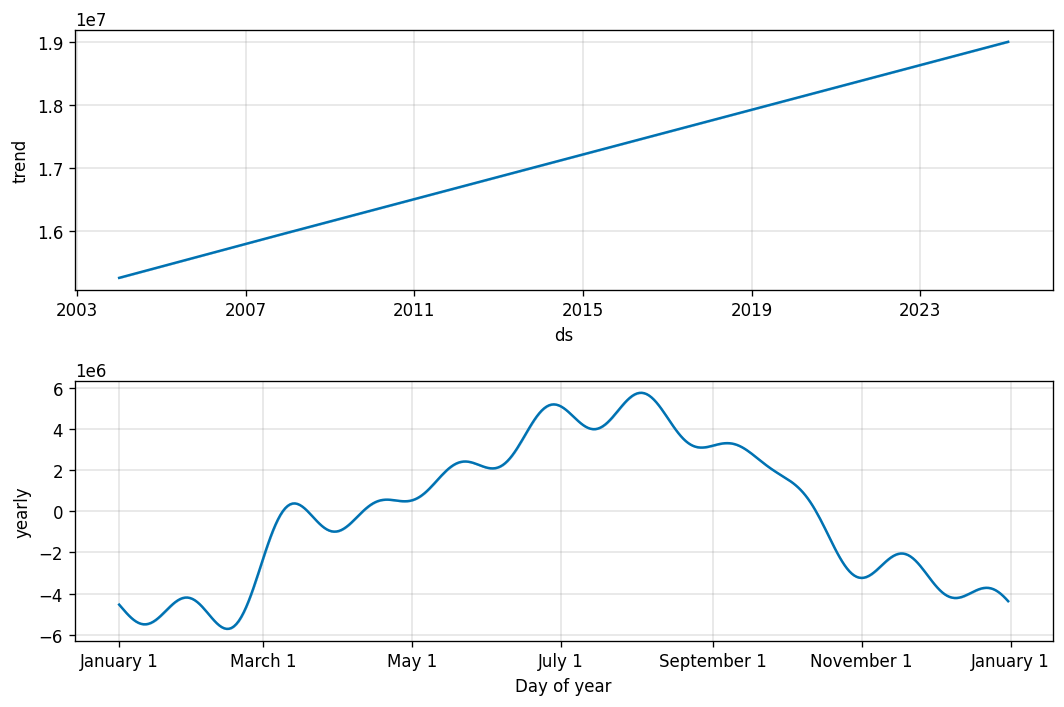

In [79]:
model_prp.plot_components(predictions_prp)
plt.show()

#### Compara los predicciones de mis modelos

In [80]:
 predictions_prp

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2004-01-01,15255261.063518,5077262.560511,16644833.770218,15255261.063518,15255261.063518,-4438341.522410,-4438341.522410,-4438341.522410,-4438341.522410,-4438341.522410,-4438341.522410,0.000000,0.000000,0.000000,10816919.541108
1,2004-02-01,15270530.782192,5196952.086577,16444624.523219,15270530.782192,15270530.782192,-4276893.761491,-4276893.761491,-4276893.761491,-4276893.761491,-4276893.761491,-4276893.761491,0.000000,0.000000,0.000000,10993637.020701
2,2004-03-01,15284815.357726,7578900.345830,18812609.028434,15284815.357726,15284815.357726,-2189716.618452,-2189716.618452,-2189716.618452,-2189716.618452,-2189716.618452,-2189716.618452,0.000000,0.000000,0.000000,13095098.739274
3,2004-04-01,15300085.076399,9013595.958155,19988148.742097,15300085.076399,15300085.076399,-940982.485403,-940982.485403,-940982.485403,-940982.485403,-940982.485403,-940982.485403,0.000000,0.000000,0.000000,14359102.590997
4,2004-05-01,15314862.223503,10731051.189055,21896630.593128,15314862.223503,15314862.223503,553203.743348,553203.743348,553203.743348,553203.743348,553203.743348,553203.743348,0.000000,0.000000,0.000000,15868065.966851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-10-01,18942407.291257,15056857.111773,26223516.548429,18942363.850797,18942451.104155,1601459.071674,1601459.071674,1601459.071674,1601459.071674,1601459.071674,1601459.071674,0.000000,0.000000,0.000000,20543866.362931
250,2024-11-01,18957454.399572,9922985.715065,21750236.763316,18957395.325785,18957511.638677,-3238657.385619,-3238657.385619,-3238657.385619,-3238657.385619,-3238657.385619,-3238657.385619,0.000000,0.000000,0.000000,15718797.013953
251,2024-12-01,18972016.117296,9745766.184000,21442561.690106,18971944.171075,18972086.306753,-3605093.180277,-3605093.180277,-3605093.180277,-3605093.180277,-3605093.180277,-3605093.180277,0.000000,0.000000,0.000000,15366922.937019
252,2025-01-01,18987063.225611,8706399.136006,20481376.856336,18986981.813085,18987147.996155,-4540910.152985,-4540910.152985,-4540910.152985,-4540910.152985,-4540910.152985,-4540910.152985,0.000000,0.000000,0.000000,14446153.072627


In [81]:
predictions_prp[['ds','yhat']]

,ds,yhat
0,2004-01-01,10816919.541108
1,2004-02-01,10993637.020701
2,2004-03-01,13095098.739274
3,2004-04-01,14359102.590997
4,2004-05-01,15868065.966851
...,...,...
249,2024-10-01,20543866.362931
250,2024-11-01,15718797.013953
251,2024-12-01,15366922.937019
252,2025-01-01,14446153.072627


In [82]:
prd_prp= predictions_prp[['ds', 'yhat']].iloc[-12:]
prd_prp = prd_prp.set_index('ds')
prd_prp

,yhat
ds,
2024-03-01,16648817.086373
2024-04-01,17912598.327737
2024-05-01,19421346.274211
2024-06-01,20999196.729998
2024-07-01,23991874.231745
2024-08-01,24669966.536627
2024-09-01,22137093.043187
2024-10-01,20543866.362931
2024-11-01,15718797.013953


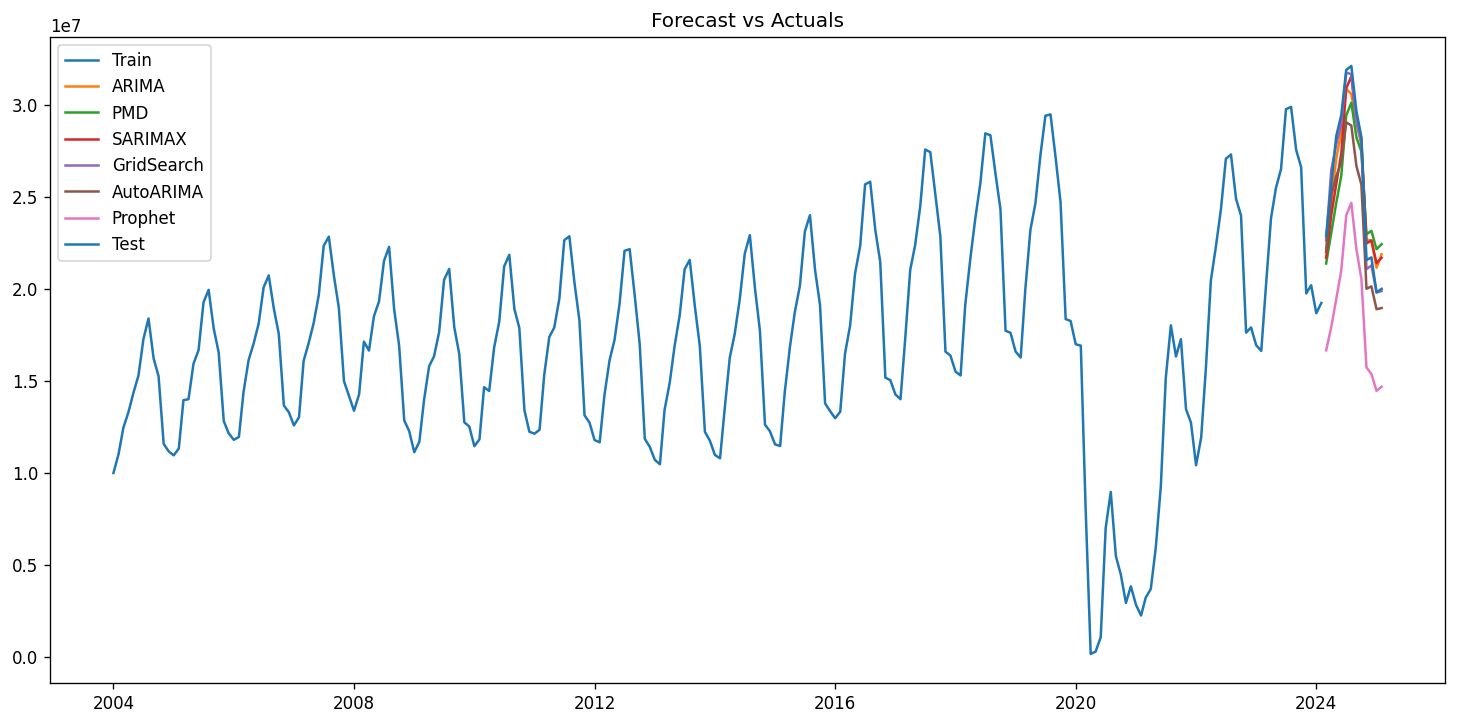

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_pmd, color=colors[2], label='PMD')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(predictions_GS, color=colors[4], label='GridSearch')
plt.plot(pred['AutoARIMA'], color=colors[5], label='AutoARIMA')
plt.plot(prd_prp, color=colors[6], label='Prophet')
plt.plot(test, color=colors[0], label='Test')

plt.title('Forecast vs Actuals')
plt.legend()
plt.show()




La prediccion con prophet no sale muy bien. Probamos a eliminar los años del COVID-19, quitamos desde febrero 2020 hasta enero 2022.

In [84]:
train_prp_filtered=train_prp[~((train_prp["ds"] >= "2020-02-01") & (train_prp["ds"] <= "2022-01-01"))]
train_prp_filtered

,ds,y
fecha,,
2004-01-01,2004-01-01,9979352.000000
2004-02-01,2004-02-01,11008703.000000
2004-03-01,2004-03-01,12434592.000000
2004-04-01,2004-04-01,13288475.000000
2004-05-01,2004-05-01,14325765.000000
...,...,...
2023-10-01,2023-10-01,26616109.000000
2023-11-01,2023-11-01,19743455.000000
2023-12-01,2023-12-01,20188071.000000


In [85]:
# Crear y entrenar el modelo
model_prp = Prophet()
model_prp.fit(train_prp_filtered)

# Generar fechas futuras para predicción
futuro = model_prp.make_future_dataframe(periods=12, freq='MS')  # Predicción para 30 días adicionales

# Hacer predicciones
predictions_prp2 = model_prp.predict(futuro)

08:07:27 - cmdstanpy - INFO - Chain [1] start processing
08:07:27 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
prd_prp2= predictions_prp2[['ds', 'yhat']].iloc[-12:]
prd_prp2.index = range(242, 242 + len(prd_prp2))
prd_prp2 = prd_prp2.set_index('ds')
prd_prp2



,yhat
ds,
2024-03-01,21658396.133589
2024-04-01,22771892.470116
2024-05-01,24569241.380850
2024-06-01,26010708.715950
2024-07-01,28670827.199546
2024-08-01,29177419.859947
2024-09-01,26519805.923088
2024-10-01,24669991.901196
2024-11-01,19960122.497352


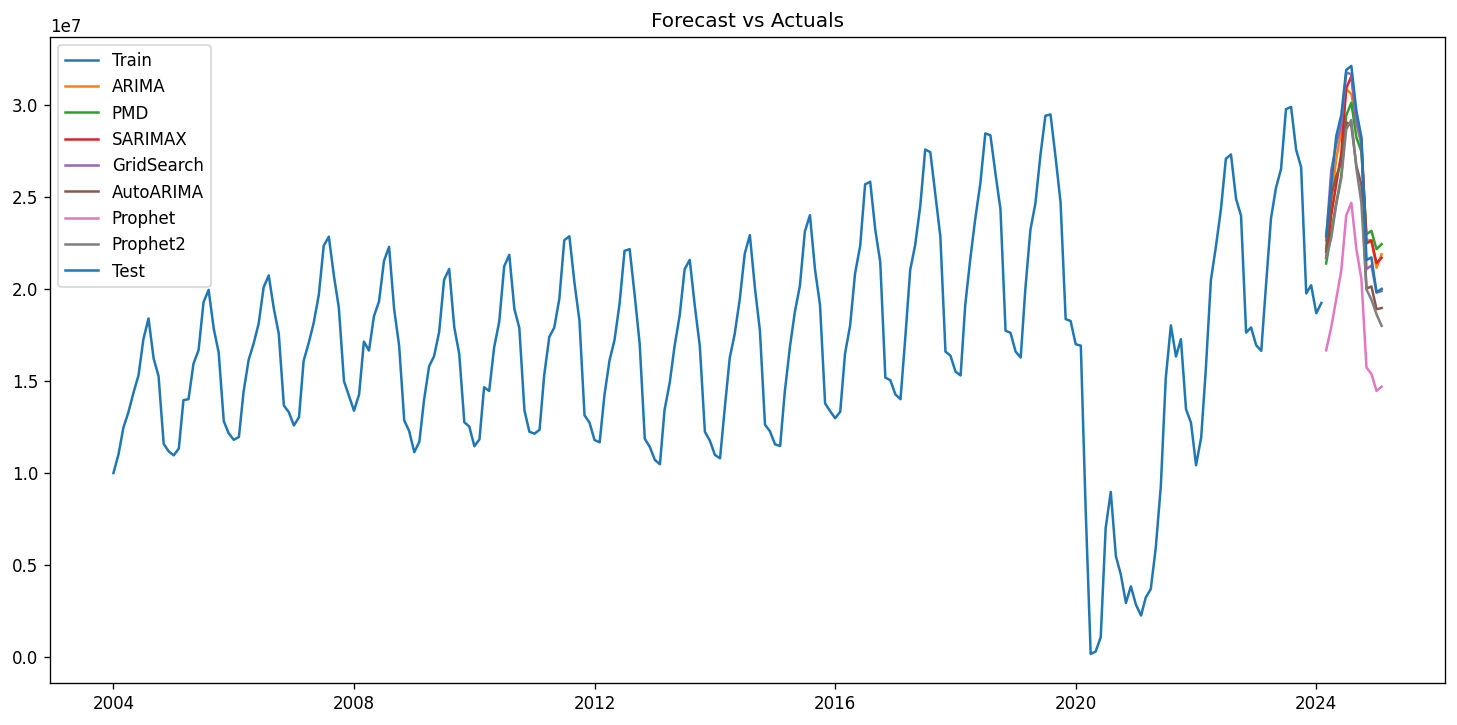

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_pmd, color=colors[2], label='PMD')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(predictions_GS, color=colors[4], label='GridSearch')
plt.plot(pred['AutoARIMA'], color=colors[5], label='AutoARIMA')
plt.plot(prd_prp, color=colors[6], label='Prophet')
plt.plot(prd_prp2, color=colors[7], label='Prophet2')
plt.plot(test, color=colors[0], label='Test')

plt.title('Forecast vs Actuals')
plt.legend()
plt.show()


In [88]:
forecast_accuracy(prd_prp2['yhat'].to_numpy(), test.to_numpy())

,Métrica,Valor
0,mape,0.098271
1,me,-2602201.418830
2,mae,2602201.418830
3,mpe,-0.098271
4,rmse,2745127.748793
5,acf1,0.311186
6,corr,0.990780
7,minmax,0.098271


La previsison que genera prophet es bastante razonable sin embargo el mape y el rmse son perores que los logrados con ARIMA. Para mejorarlo se podría hacer optimizacion de hiperparámetros

#### 7.2 Optimizacion de hiperparámetros

**additive**: Los picos vaslen siempre lo mismo en vbalor absoluto. Ej +200 sobre la media  
**multiplicative**: los picos valen lo mismo pero porcentualmente: 20% sobre la media  
**prior_scale_values** es un coeficiente bayesiano de regularizacion: valor bajop rígido, poco sensible a los datos; valor a alto se adata mucho a los datos
 

In [89]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
import numpy as np
import itertools

# Crear división temporal con 3 particiones
tscv = TimeSeriesSplit(n_splits=3)

# Función para evaluar Prophet con TimeSeriesSplit
def evaluar_prophet(params, df):
    errores = []
    
    for train_idx, test_idx in tscv.split(df):
        df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
        
        # Entrenar Prophet con los datos de entrenamiento
        modelo = Prophet(changepoint_prior_scale=params["changepoint_prior_scale"],
                         seasonality_mode=params["seasonality_mode"])
        modelo.fit(df_train)
        
        # Hacer predicciones en el conjunto de prueba
        predicciones = modelo.predict(df_test)
        
        # Calcular el RMSE
        rmse = np.sqrt(mean_squared_error(df_test["y"], predicciones["yhat"]))
        errores.append(rmse)
    
    return np.mean(errores)  # Promedio de los errores

# Definir la cuadrícula de hiperparámetros

changepoint_prior_scale_values = [0.001, 0.01, 0.02, 0.016, 0.0178, 0.018, 0.0182, 0.0185, 0.019, 0.022 , 0.05, 0.1,  0.2]
seasonality_mode_values = ["additive", "multiplicative"]

# Generar todas las combinaciones posibles
param_grid = [
    {"changepoint_prior_scale": cps, "seasonality_mode": sm}
    for cps, sm in itertools.product(changepoint_prior_scale_values, seasonality_mode_values)
]


# Evaluar cada combinación de hiperparámetros
mejor_param = None
mejor_rmse = float("inf")

for params in param_grid:
    rmse_actual = evaluar_prophet(params, train_prp_filtered)
    print(f"Probando {params}, RMSE obtenido: {rmse_actual}")
    
    if rmse_actual < mejor_rmse:
        mejor_rmse = rmse_actual
        mejor_param = params

print(f"\nMejores hiperparámetros encontrados: {mejor_param} con RMSE de {mejor_rmse}")


08:15:06 - cmdstanpy - INFO - Chain [1] start processing
08:15:06 - cmdstanpy - INFO - Chain [1] done processing
08:15:07 - cmdstanpy - INFO - Chain [1] start processing
08:15:07 - cmdstanpy - INFO - Chain [1] done processing
08:15:07 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:15:07 - cmdstanpy - INFO - Chain [1] start processing
08:15:08 - cmdstanpy - INFO - Chain [1] done processing
08:15:08 - cmdstanpy - INFO - Chain [1] start processing
08:15:08 - cmdstanpy - INFO - Chain [1] done processing
08:15:08 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:15:08 - cmdstanpy - INFO - Chain [1] start processing
08:15:08 - cmdstanpy - INFO - Chain [1] done processing
08:15:08 - cmdstanpy - INFO - Chain [1] start processing


Probando {'changepoint_prior_scale': 0.001, 'seasonality_mode': 'additive'}, RMSE obtenido: 3417511.662799911


08:15:09 - cmdstanpy - INFO - Chain [1] done processing
08:15:09 - cmdstanpy - INFO - Chain [1] start processing
08:15:09 - cmdstanpy - INFO - Chain [1] done processing
08:15:09 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:15:09 - cmdstanpy - INFO - Chain [1] start processing
08:15:09 - cmdstanpy - INFO - Chain [1] done processing
08:15:09 - cmdstanpy - INFO - Chain [1] start processing
08:15:09 - cmdstanpy - INFO - Chain [1] done processing
08:15:09 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:15:10 - cmdstanpy - INFO - Chain [1] start processing
08:15:10 - cmdstanpy - INFO - Chain [1] done processing
08:15:10 - cmdstanpy - INFO - Chain [1] start processing


Probando {'changepoint_prior_scale': 0.001, 'seasonality_mode': 'multiplicative'}, RMSE obtenido: 3218021.6537708454


08:15:10 - cmdstanpy - INFO - Chain [1] done processing
08:15:10 - cmdstanpy - INFO - Chain [1] start processing
08:15:10 - cmdstanpy - INFO - Chain [1] done processing
08:15:10 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:15:10 - cmdstanpy - INFO - Chain [1] start processing
08:15:11 - cmdstanpy - INFO - Chain [1] done processing
08:15:11 - cmdstanpy - INFO - Chain [1] start processing
08:15:11 - cmdstanpy - INFO - Chain [1] done processing
08:15:11 - cmdstanpy - INFO - Chain [1] start processing


...

Probando {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}, RMSE obtenido: 3672843.959715845


08:15:31 - cmdstanpy - INFO - Chain [1] done processing
08:15:32 - cmdstanpy - INFO - Chain [1] start processing
08:15:32 - cmdstanpy - INFO - Chain [1] done processing
08:15:32 - cmdstanpy - INFO - Chain [1] start processing
08:15:32 - cmdstanpy - INFO - Chain [1] done processing
08:15:32 - cmdstanpy - INFO - Chain [1] start processing


Probando {'changepoint_prior_scale': 0.2, 'seasonality_mode': 'additive'}, RMSE obtenido: 4095652.3156705387


08:15:33 - cmdstanpy - INFO - Chain [1] done processing
08:15:33 - cmdstanpy - INFO - Chain [1] start processing
08:15:33 - cmdstanpy - INFO - Chain [1] done processing
08:15:33 - cmdstanpy - INFO - Chain [1] start processing
08:15:33 - cmdstanpy - INFO - Chain [1] done processing


Probando {'changepoint_prior_scale': 0.2, 'seasonality_mode': 'multiplicative'}, RMSE obtenido: 3941503.0980132725

Mejores hiperparámetros encontrados: {'changepoint_prior_scale': 0.016, 'seasonality_mode': 'multiplicative'} con RMSE de 2273521.75860694


In [90]:
mejor_param
#cps_value = mejor_param['changepoint_prior_scale']
#seasonality = mejor_param['seasonality_mode']
#cps_value

{'changepoint_prior_scale': 0.016, 'seasonality_mode': 'multiplicative'}

In [91]:
# Crear y entrenar el modelo
model_prp = Prophet(changepoint_prior_scale=  mejor_param['changepoint_prior_scale'], seasonality_mode=mejor_param['seasonality_mode'])
#model_prp = Prophet(changepoint_prior_scale= 0.0178, seasonality_mode='multiplicative')

model_prp.fit(train_prp_filtered)

# Generar fechas futuras para predicción
futuro = model_prp.make_future_dataframe(periods=12, freq='MS')  # Predicción para 30 días adicionales

# Hacer predicciones
predictions_prp3 = model_prp.predict(futuro)

08:15:33 - cmdstanpy - INFO - Chain [1] start processing
08:15:33 - cmdstanpy - INFO - Chain [1] done processing


In [92]:
prd_prp3= predictions_prp3[['ds', 'yhat']].iloc[-12:]
prd_prp3.index = range(242, 242 + len(prd_prp3))
prd_prp3 = prd_prp3.set_index('ds')
prd_prp3



,yhat
ds,
2024-03-01,21079039.775363
2024-04-01,23761440.734127
2024-05-01,25824257.383247
2024-06-01,27838854.337148
2024-07-01,31371924.141610
2024-08-01,31967502.372868
2024-09-01,28649331.982844
2024-10-01,26383599.568697
2024-11-01,19470522.873309


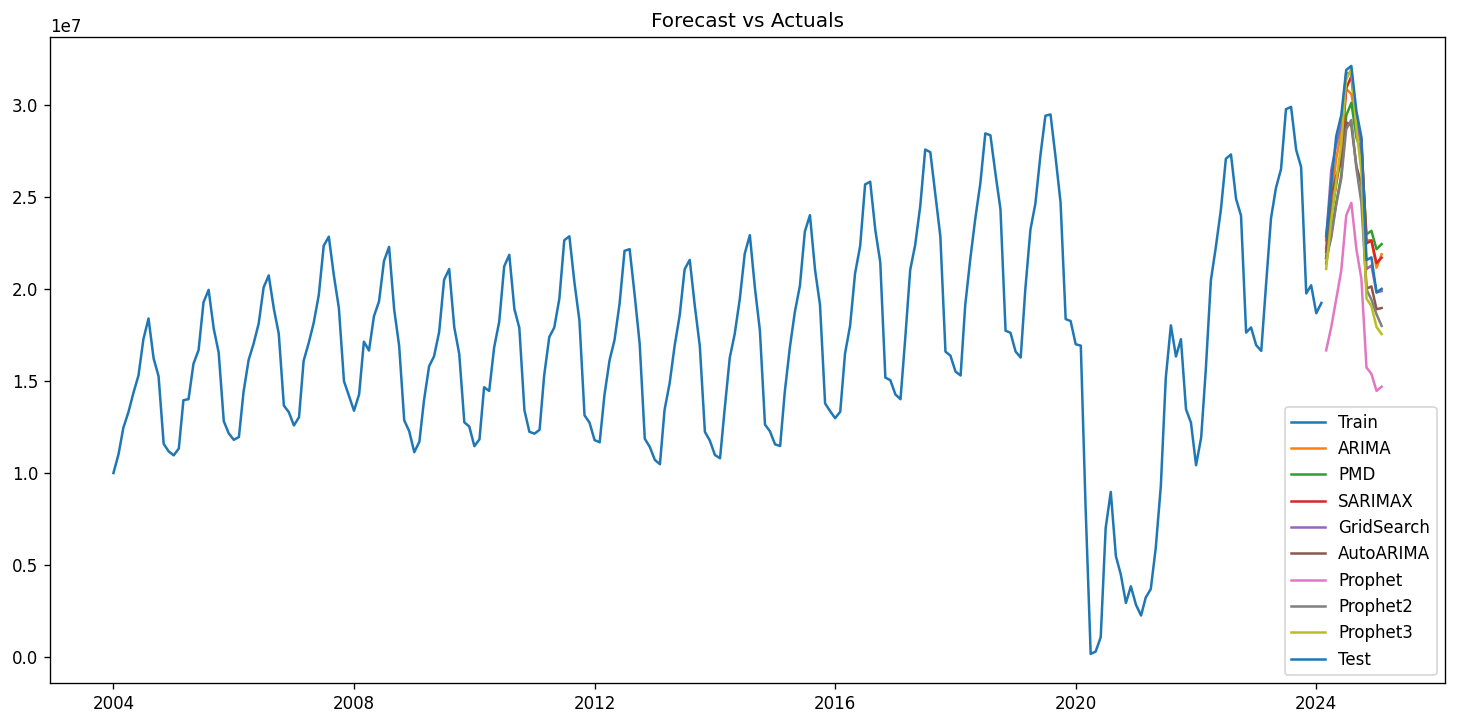

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_pmd, color=colors[2], label='PMD')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(predictions_GS, color=colors[4], label='GridSearch')
plt.plot(pred['AutoARIMA'], color=colors[5], label='AutoARIMA')
plt.plot(prd_prp, color=colors[6], label='Prophet')
plt.plot(prd_prp2, color=colors[7], label='Prophet2')
plt.plot(prd_prp3, color=colors[8], label='Prophet3')
plt.plot(test, color=colors[0], label='Test')

plt.title('Forecast vs Actuals')
plt.legend()
plt.show()

In [95]:
forecast_accuracy(prd_prp3['yhat'].to_numpy(), test.to_numpy())

,Métrica,Valor
0,mape,0.071000
1,me,-1698642.813251
2,mae,1698642.813251
3,mpe,-0.071000
4,rmse,1853755.292472
5,acf1,0.567034
6,corr,0.994970
7,minmax,0.071000


#### 8. Alisado Exponencial
El alisado exponencial es una técnica de modelado de series temporales que enfatiza los valores recientes mediante un factor de suavizamiento. Es útil para capturar tendencias y estacionalidades. El modelo es más sencillo que ARIMA.

In [96]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# Ajustar modelo Holt-Winters
ESmodel = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12)
ESmodel_fit = ESmodel.fit()

# Generar predicciones futuras
ES_predictions = ESmodel_fit.forecast(12)
ES_predictions

2024-03-01   21840789.271973
2024-04-01   23280039.449688
2024-05-01   24551208.435058
2024-06-01   25874048.209868
2024-07-01   28336967.090680
2024-08-01   28561539.302837
2024-09-01   26173528.220351
2024-10-01   24927594.509534
2024-11-01   20575731.119484
2024-12-01   20792786.963456
2025-01-01   20056276.350000
2025-02-01   20564853.133235
Freq: MS, dtype: float64

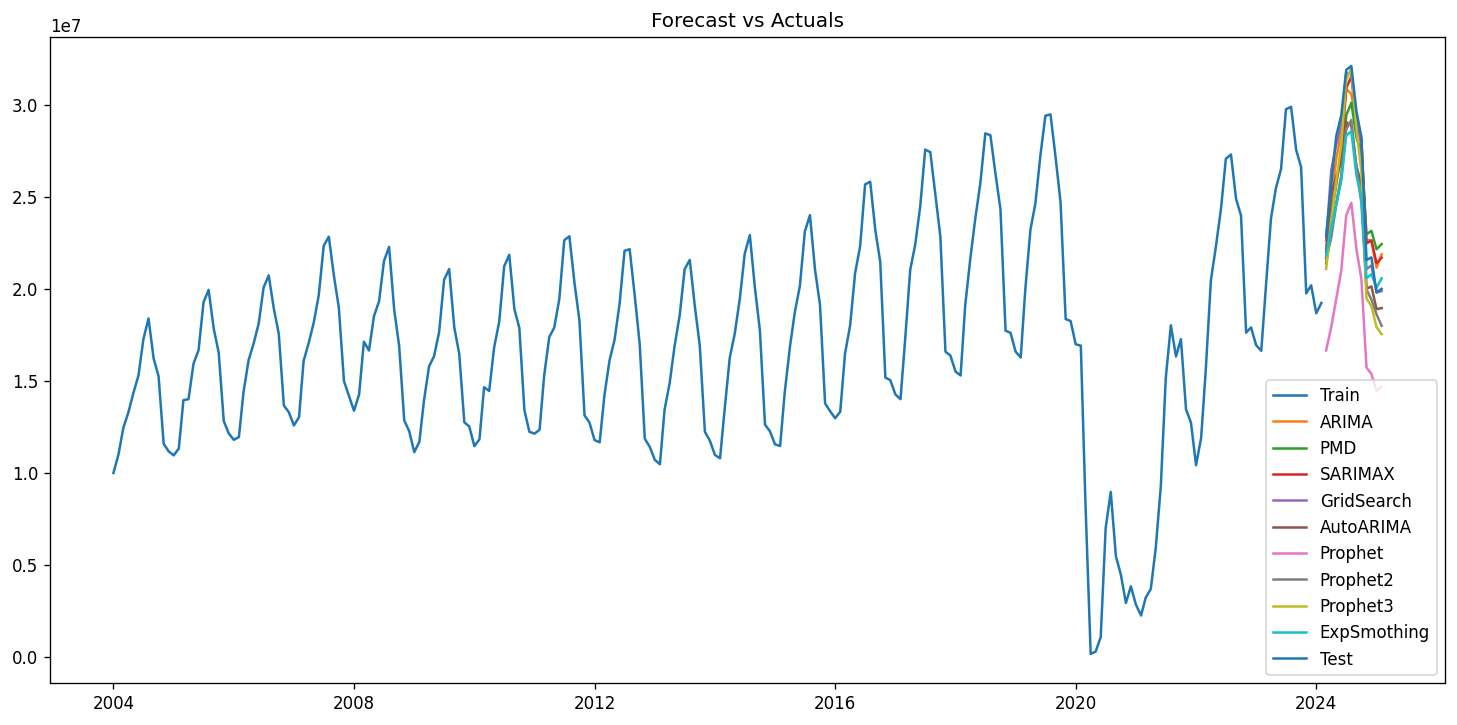

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

colors = plt.cm.tab10.colors  # 10 colores bien diferenciados

plt.plot(train, color=colors[0], label='Train')
plt.plot(predictions, color=colors[1], label='ARIMA')
plt.plot(predictions_pmd, color=colors[2], label='PMD')
plt.plot(predictions_SARIMAX, color=colors[3], label='SARIMAX')
plt.plot(predictions_GS, color=colors[4], label='GridSearch')
plt.plot(pred['AutoARIMA'], color=colors[5], label='AutoARIMA')
plt.plot(prd_prp, color=colors[6], label='Prophet')
plt.plot(prd_prp2, color=colors[7], label='Prophet2')
plt.plot(prd_prp3, color=colors[8], label='Prophet3')
plt.plot(ES_predictions, color=colors[9], label='ExpSmothing')

plt.plot(test, color=colors[0], label='Test')

plt.title('Forecast vs Actuals')
plt.legend()
plt.show()


In [98]:
forecast_accuracy(ES_predictions.to_numpy(), test.to_numpy())

,Métrica,Valor
0,mape,0.081434
1,me,-2141477.578653
2,mae,2279190.492525
3,mpe,-0.074525
4,rmse,2647156.895991
5,acf1,0.667583
6,corr,0.987602
7,minmax,0.081354
